In [1]:
import csv
import monpa
from monpa import utils
from collections import Counter
import pandas as pd
import numpy as np
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer

+---------------------------------------------------------------------+
  Welcome to MONPA: Multi-Objective NER POS Annotator for Chinese
+---------------------------------------------------------------------+
已找到 model檔。Found model file.


In [2]:
tf_counter_bull = Counter()
df_counter_bull = Counter()

f = open('2722_Bull_news.csv', newline='', encoding='utf-8')
rows = csv.reader(f, delimiter=',')
i = 0
for row in rows:
    # print(row[1], row[2])
    i = i + 1
    if i > 1:
        query = row[1]+' ' + row[2]
        df_temp = Counter()
        sentence_list = utils.short_sentence(query)
        for item in sentence_list:
            word_cut = monpa.cut(item)
            for term in word_cut:
                term = term.strip()
                if (len(term) > 1):
                    tf_counter_bull[term] += 1
                    if (df_temp[term] == 0):
                        df_temp[term] = 1
        df_counter_bull += df_temp

f.close()

In [3]:
df_counter_bull

Counter({'夏都': 246,
         '台股': 177,
         '指數': 174,
         '2722': 172,
         '觀光': 160,
         '漲停': 151,
         '寒舍': 137,
         '表現': 134,
         '台積電': 131,
         '股價': 130,
         '台北': 125,
         '漲幅': 123,
         '族群': 121,
         '市場': 116,
         '聯發科': 114,
         '上漲': 113,
         '雲品': 108,
         '震盪': 106,
         '類股': 102,
         '加權': 101,
         '美股': 101,
         '下跌': 100,
         '今日': 98,
         '法人': 96,
         '持續': 93,
         'KY': 93,
         '鳳凰': 91,
         '電子': 90,
         '外資': 89,
         'AI': 88,
         '帶動': 86,
         '2739': 86,
         '2330': 85,
         '股市': 84,
         '大漲': 84,
         '強勢': 82,
         '加上': 79,
         '記者': 79,
         '表示': 79,
         '10': 78,
         '終場': 78,
         '鴻海': 76,
         '觀光股': 74,
         '美國': 74,
         '時報': 73,
         '今年': 72,
         '跌幅': 71,
         '資金': 71,
         '2454': 71,
         '營收': 70,
         '其中': 69

In [4]:
tf_counter_bull

Counter({'指數': 661,
         '台股': 548,
         '股價': 437,
         '夏都': 364,
         '觀光': 362,
         '上漲': 345,
         '漲停': 341,
         '表現': 286,
         '漲幅': 266,
         '類股': 261,
         '族群': 258,
         '台積電': 248,
         '外資': 247,
         '今日': 237,
         '下跌': 236,
         '震盪': 214,
         '市場': 211,
         'TW': 207,
         '2722': 206,
         '法人': 199,
         '寒舍': 190,
         '台北': 186,
         '公司': 174,
         '美股': 168,
         '跌幅': 165,
         'KY': 165,
         '電子': 163,
         'AI': 163,
         '終場': 162,
         '持續': 162,
         '美國': 159,
         '買超': 158,
         '聯發科': 155,
         '大漲': 155,
         '今年': 154,
         '交易': 152,
         '股市': 149,
         '營收': 147,
         '強勢': 145,
         '早盤': 144,
         '新高': 143,
         '雲品': 135,
         '帶動': 133,
         '觀光股': 132,
         '資金': 124,
         '10': 120,
         '加權': 119,
         '今天': 115,
         '預期': 113,
         '鳳凰': 

In [5]:
tfidf_bull = Counter()
N_bull = 269
import numpy as np
for term, tf in tf_counter_bull.items():
    # print(v1)
    df = df_counter_bull.get(term, 0)
    if df > 0:
        tfidf_bull[term] = (1 + np.log10(tf)) * (np.log10((N_bull / df)))

len(tfidf_bull)

10801

In [6]:
tf_counter_bear = Counter()
df_counter_bear = Counter()

f = open('2722_Bear_news.csv', newline='', encoding='utf-8')
rows = csv.reader(f, delimiter=',')
i = 0
for row in rows:
    # print(row[1], row[2])
    i = i + 1
    if i > 1:
        query = row[1]+' ' + row[2]
        df_temp = Counter()
        sentence_list = utils.short_sentence(query)
        for item in sentence_list:
            word_cut = monpa.cut(item)
            for term in word_cut:
                term = term.strip()
                if (len(term) > 1):
                    tf_counter_bear[term] += 1
                    if (df_temp[term] == 0):
                        df_temp[term] = 1
        df_counter_bear += df_temp

f.close()

In [7]:
tf_counter_bear

Counter({'台股': 384,
         '指數': 383,
         '觀光': 332,
         '股價': 329,
         '夏都': 271,
         '漲幅': 251,
         '上漲': 245,
         '族群': 238,
         '表現': 229,
         '漲停': 220,
         '今日': 218,
         '下跌': 195,
         '台積電': 180,
         '法人': 178,
         'AI': 176,
         '類股': 175,
         '公司': 174,
         '外資': 167,
         '今年': 163,
         '市場': 152,
         '持續': 142,
         'KY': 136,
         '營收': 134,
         '震盪': 129,
         '大漲': 124,
         '跌幅': 124,
         '台北': 123,
         '2722': 120,
         '10': 119,
         '終場': 119,
         '電子': 116,
         '寒舍': 112,
         '投資': 112,
         '觀光股': 111,
         '美股': 111,
         '早盤': 110,
         '題材': 108,
         '概念股': 106,
         '收盤': 102,
         '台灣': 97,
         '旅遊': 97,
         '飯店': 96,
         '兩岸': 95,
         '雲品': 95,
         '獲利': 93,
         '上市': 93,
         '資金': 91,
         '新高': 90,
         '加權': 90,
         '股市': 89,
      

In [8]:
df_counter_bear

Counter({'夏都': 189,
         '台股': 133,
         '觀光': 131,
         '指數': 115,
         '漲幅': 102,
         '2722': 97,
         '族群': 95,
         '表現': 93,
         '台積電': 91,
         '寒舍': 91,
         '上漲': 88,
         '股價': 84,
         '漲停': 84,
         '今日': 83,
         '市場': 79,
         '台北': 79,
         '雲品': 79,
         '法人': 78,
         'KY': 78,
         '大漲': 77,
         '持續': 76,
         '類股': 76,
         '10': 73,
         '震盪': 71,
         '下跌': 71,
         '鳳凰': 67,
         '電子': 66,
         '加權': 66,
         '外資': 64,
         '記者': 64,
         '美股': 63,
         '股市': 63,
         'AI': 63,
         '終場': 62,
         '聯發科': 61,
         '相關': 61,
         '雄獅': 60,
         '今年': 60,
         '收盤': 60,
         '帶動': 59,
         '台灣': 59,
         '鴻海': 59,
         '大盤': 58,
         '方面': 58,
         '表示': 57,
         '跌幅': 57,
         '資金': 56,
         '成交量': 56,
         '其中': 55,
         '概念股': 55,
         '加上': 54,
         '上市': 54,
 

In [9]:
tfidf_bear = Counter()
N_bear = 220
import numpy as np
for term, tf in tf_counter_bear.items():
    # print(v1)
    df = df_counter_bear.get(term, 0)
    if df > 0:
        tfidf_bear[term] = (1 + np.log10(tf)) * (np.log10((N_bear / df)))

tfidf_bear

Counter({'工作': 5.2828014673886985,
         '龍巖': 5.097325520750979,
         '雷科': 5.027138986721114,
         '颱風': 4.781804526179172,
         '有價': 4.684845361644412,
         '銅價': 4.684845361644412,
         '林修禾': 4.577661977937579,
         '商辦': 4.577661977937579,
         '撮合': 4.457841149175566,
         '維持率': 4.457841149175566,
         '電線': 4.457841149175566,
         '墾丁': 4.44225677847302,
         'LINE Pay': 4.381090073446545,
         '建置': 4.321999497269994,
         '塔墓': 4.321999497269994,
         '點數': 4.165181818831012,
         '勞資': 4.165181818831012,
         '發展署': 4.165181818831012,
         '土地': 4.165181818831012,
         '回饋': 4.08278537031645,
         '低溫': 3.9797058721932923,
         '照明': 3.9797058721932923,
         '協議': 3.9797058721932923,
         '缺工': 3.9797058721932923,
         '掉到': 3.9797058721932923,
         '發文': 3.9797058721932923,
         '石化': 3.9797058721932923,
         '動產': 3.9797058721932923,
         '帳面': 3.979705872193292

In [10]:
data = pd.read_csv('2722_news.csv')
data.shape

(683, 3)

計算lift: 先匯入所有夏都資料

In [11]:
tf_counter_2722 = Counter()
df_counter_2722 = Counter()

f = open('2722_news.csv', newline='', encoding='utf-8')
rows = csv.reader(f, delimiter=',')
i = 0
for row in rows:
    # print(row[1], row[2])
    i = i + 1
    if i > 1:
        query = row[1]+' ' + row[2]
        df_temp = Counter()
        sentence_list = utils.short_sentence(query)
        for item in sentence_list:
            word_cut = monpa.cut(item)
            for term in word_cut:
                term = term.strip()
                if (len(term) > 1):
                    tf_counter_2722[term] += 1
                    if (df_temp[term] == 0):
                        df_temp[term] = 1
        df_counter_2722 += df_temp

f.close()

In [12]:
tf_counter_2722

Counter({'指數': 1417,
         '台股': 1321,
         '股價': 1032,
         '觀光': 930,
         '夏都': 906,
         '上漲': 807,
         '漲幅': 739,
         '表現': 707,
         '族群': 687,
         '漲停': 683,
         '今日': 611,
         '台積電': 580,
         '類股': 570,
         '下跌': 569,
         '外資': 546,
         '公司': 538,
         '市場': 523,
         '法人': 503,
         '震盪': 485,
         'AI': 452,
         '2722': 450,
         'TW': 422,
         '持續': 422,
         '營收': 415,
         '今年': 407,
         '寒舍': 401,
         '台北': 401,
         '美股': 391,
         '大漲': 389,
         '電子': 381,
         '終場': 379,
         'KY': 372,
         '跌幅': 372,
         '美國': 333,
         '早盤': 331,
         '新高': 329,
         '交易': 328,
         '雲品': 328,
         '買超': 320,
         '觀光股': 315,
         '股市': 309,
         '10': 304,
         '強勢': 303,
         '旅遊': 302,
         '資金': 294,
         '聯發科': 291,
         '預期': 281,
         '帶動': 276,
         '投資': 272,
         '加權

In [13]:
df_counter_2722

Counter({'夏都': 605,
         '台股': 427,
         '指數': 393,
         '觀光': 389,
         '2722': 367,
         '漲幅': 317,
         '表現': 312,
         '寒舍': 309,
         '漲停': 306,
         '股價': 303,
         '族群': 296,
         '台積電': 292,
         '上漲': 278,
         '台北': 265,
         '雲品': 264,
         '市場': 263,
         '類股': 250,
         '今日': 245,
         '震盪': 243,
         '法人': 237,
         '下跌': 235,
         '聯發科': 229,
         '持續': 226,
         '美股': 225,
         '大漲': 222,
         'KY': 217,
         '加權': 217,
         '鳳凰': 215,
         '電子': 213,
         '外資': 205,
         'AI': 201,
         '股市': 199,
         '10': 196,
         '加上': 194,
         '帶動': 187,
         '今年': 187,
         '鴻海': 186,
         '終場': 186,
         '強勢': 185,
         '表示': 184,
         '記者': 183,
         '相關': 182,
         '資金': 175,
         '跌幅': 173,
         '大盤': 172,
         '其中': 168,
         '觀光股': 166,
         '美國': 166,
         '成交量': 165,
         '2330

In [14]:
Bull_lift = Counter()
N_shiadu = 683
for term, df in df_counter_bull.items():
    if term in df_counter_2722:
        Bull_lift[term] = (df_counter_bull.get(term, 0) / N_bull) / (df_counter_2722.get(term, 0) / N_shiadu)

Bear_lift = Counter()
for term, df in df_counter_bear.items():
    if term in df_counter_2722:
        Bear_lift[term] = (df_counter_bear.get(term, 0) / N_bear) / (df_counter_2722.get(term, 0) / N_shiadu)
Bear_lift

Counter({'現增': 3.1045454545454545,
         '抽中': 3.1045454545454545,
         '葉佳華': 3.1045454545454545,
         '894': 3.1045454545454545,
         '11.12': 3.1045454545454545,
         '591.26': 3.1045454545454545,
         '脫罩': 3.1045454545454545,
         '熬出': 3.1045454545454545,
         '....': 3.1045454545454545,
         '26.70': 3.1045454545454545,
         '24.69': 3.1045454545454545,
         '14.52': 3.1045454545454545,
         '36.65': 3.1045454545454545,
         '75.69': 3.1045454545454545,
         '33.42': 3.1045454545454545,
         '202': 3.1045454545454545,
         '翻桌率': 3.1045454545454545,
         '來客數': 3.1045454545454545,
         '110萬': 3.1045454545454545,
         '15.37': 3.1045454545454545,
         '1～': 3.1045454545454545,
         '財富': 3.1045454545454545,
         '必修課': 3.1045454545454545,
         '11.1': 3.1045454545454545,
         '591.2': 3.1045454545454545,
         '團費': 3.1045454545454545,
         '充實': 3.1045454545454545,
         '85

In [15]:
Bear_mi = Counter()
for term, df in df_counter_bear.items():
    if term in df_counter_2722:
        Bear_mi[term] = np.log10(df_counter_bear.get(term, 0) / (N_bear*df_counter_2722.get(term, 0)))

Bull_mi = Counter()
for term, df in df_counter_bull.items():
    if term in df_counter_2722:
        Bull_mi[term] = np.log10(df_counter_bull.get(term, 0) / (N_bull*df_counter_2722.get(term, 0)))
Bear_mi

Counter({'現增': -2.342422680822206,
         '抽中': -2.342422680822206,
         '葉佳華': -2.342422680822206,
         '894': -2.342422680822206,
         '11.12': -2.342422680822206,
         '591.26': -2.342422680822206,
         '脫罩': -2.342422680822206,
         '熬出': -2.342422680822206,
         '....': -2.342422680822206,
         '26.70': -2.342422680822206,
         '24.69': -2.342422680822206,
         '14.52': -2.342422680822206,
         '36.65': -2.342422680822206,
         '75.69': -2.342422680822206,
         '33.42': -2.342422680822206,
         '202': -2.342422680822206,
         '翻桌率': -2.342422680822206,
         '來客數': -2.342422680822206,
         '110萬': -2.342422680822206,
         '15.37': -2.342422680822206,
         '1～': -2.342422680822206,
         '財富': -2.342422680822206,
         '必修課': -2.342422680822206,
         '11.1': -2.342422680822206,
         '591.2': -2.342422680822206,
         '團費': -2.342422680822206,
         '充實': -2.342422680822206,
         '85

In [16]:
#全部乘積

All_bull = Counter()

for term, tf in tfidf_bull.items():
    if term in Bull_lift:
        if term in Bull_mi:
            All_bull[term] = tfidf_bull.get(term, 0) * Bull_lift.get(term, 0) * Bull_mi.get(term, 0)
All_bear = Counter()
for term, tf in tfidf_bear.items():
    if term in Bear_lift:
        if term in Bear_mi:
            All_bear[term] = tfidf_bear.get(term, 0) * Bear_lift.get(term, 0) * Bear_mi.get(term, 0)
All_bear

Counter({'夏都': -0.625399462360149,
         '快速': -1.385987627958621,
         '6531': -1.4535003721970716,
         '周一': -1.52838151084459,
         '3041': -1.52838151084459,
         '共計': -1.52838151084459,
         '特定': -1.6119385931408947,
         '2388': -1.6119385931408947,
         '榮剛': -1.7058125461657092,
         '5364': -1.7058125461657092,
         '各自': -1.81209220766378,
         'ChatGPT': -1.81209220766378,
         '4967': -1.81209220766378,
         '官田鋼': -1.81209220766378,
         '王逸芯': -1.81209220766378,
         '精剛': -1.81209220766378,
         '對象': -1.9334799088253982,
         '3252': -1.9334799088253982,
         '有撐': -1.9334799088253982,
         '0.27': -1.9334799088253982,
         '千附精密': -1.9334799088253982,
         '6829': -1.9334799088253982,
         '一月': -2.073536941375234,
         '1301': -2.073536941375234,
         '2883': -2.073536941375234,
         '敦泰': -2.073536941375234,
         '資服': -2.073536941375234,
         '6414': -2.0735

In [17]:
print(len(All_bear), len(All_bull))

10281 10801


In [18]:
common_number = 1400

f = open('bull_tfidf.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f)
for term in tfidf_bull.most_common(common_number):
  writer.writerow(term)
f.close()
f = open('bear_tfidf.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f)
for term in tfidf_bear.most_common(common_number):
  writer.writerow(term)
f.close()

f = open('bull_lift.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f)
for term in Bull_lift.most_common(common_number):
  writer.writerow(term)
f.close()
f = open('bear_lift.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f)
for term in Bear_lift.most_common(common_number):
  writer.writerow(term)
f.close()  

f = open('bull_mi.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f)
for term in Bull_mi.most_common(common_number):
  writer.writerow(term)
f.close()
f = open('bear_mi.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f)
for term in Bear_mi.most_common(common_number):
  writer.writerow(term)
f.close()


In [19]:
common_number = 1500
f = open('bull_all.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f)
for term in All_bull.most_common(common_number):
  writer.writerow(term)
f.close()
f = open('bear_all.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f)
for term in All_bear.most_common(common_number):
  writer.writerow(term)
f.close()

In [20]:
common_number = 1200

f = open('bull_tf.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f)
for term in tf_counter_bull.most_common(common_number):
  writer.writerow(term)
f.close()

f = open('bear_tf.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f)
for term in tf_counter_bear.most_common(common_number):
  writer.writerow(term)
f.close()

f = open('bull_df.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f)
for term in df_counter_bull.most_common(common_number):
  writer.writerow(term)
f.close()

f = open('bear_df.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f)
for term in df_counter_bear.most_common(common_number):
  writer.writerow(term)
f.close()

以下是只有把文件資料斷詞，未篩選。作為後續訓練使用的文字集合

In [21]:
bull_result = list()
f = open('2722_Bull_news.csv', newline='', encoding='utf-8')
rows = csv.reader(f, delimiter=',')

i=0
for row in rows:
  i=i+1 

  if(i>1): 
    query=row[0]+' '+row[1]
    str=''
    sentence_list = utils.short_sentence(query)
    for item in sentence_list:
      result_cut = monpa.cut(item)
      for term in result_cut:
        term=term.strip()
        if(len(term)>1):
           str=str+' '+term
    print(i, str)
    bull_result.append(str)
    
f.close()
bull_result

2  2023 02 15 台股 台積 重挫 大跌 221 15432 摜破 10
3  2023 02 22 台股 普丁 搗亂 電金 大盤 失守 月線 跌破 15400
4  2023 02 22 焦點股 觀光 族群 聯袂 亮燈 漲停 家數 大盤 4成
5  2023 02 22 美股 重挫 科技 領跌 台股 早盤 217 新聞
6  2023 02 23 台積電 回穩 運輸 觀光 強攻 台股 200
7  2023 02 23 台股 200 台積電 大漲 14
8  2023 03 02 速報 觀光類 指數 類股 表現 強勁 漲幅 3.9 成交額 19.90
9  2023 03 02 台股 早盤 40 航運 亮眼 觀光
10  2023 03 02 美股 收黑 台股 走低 發現 觀光股 受惠 漲停
11  2023 03 02 台股 民視 收盤 翻紅 專家 留意
12  2023 05 22 速報 夏都 2722 急跌 3.48 55.6 成交 828
13  2023 05 22 速報 夏都 2722 2.34 56.5 成交 1,159
14  2023 05 23 速報 觀光類 指數 類股 表現 強勁 漲幅 2.43 成交額 33.82億
15  2023 05 24 速報 夏都 2722 股價 大漲 67.7 漲幅 7.12
16  2023 05 24 速報 觀光類 指數 類股 表現 強勁 漲幅 2.02 成交額 10.38億
17  2023 05 24 速報 夏都 2722 股價 漲停 漲停價 69.5 成交 1,259
18  2023 05 24 台股 收盤 下跌 28.71
19  2023 05 24 大強 漲股 整理 台股 降溫 好事 拉回 萬六 買點
20  2023 06 06 台股 走揚盤 逼近 16800 觀光 族群 強勢
21  2023 06 06 台股 觀光 汽車 撐場 終場 小漲 47 16761.66
22  2023 06 13 台股 再現 電子股 狂歡 大漲 200 衝破 萬七
23  2023 06 19 速報 觀光類 指數 類股 表現 強勁 漲幅 2.1 成交額 3.71
24  2023 06 19 台股 早盤 下挫 權王 回檔 軍工 觀光 族群 閃亮
25  2023 06 20 台股 早盤 80 觀光 旅

[' 2023 02 15 台股 台積 重挫 大跌 221 15432 摜破 10',
 ' 2023 02 22 台股 普丁 搗亂 電金 大盤 失守 月線 跌破 15400',
 ' 2023 02 22 焦點股 觀光 族群 聯袂 亮燈 漲停 家數 大盤 4成',
 ' 2023 02 22 美股 重挫 科技 領跌 台股 早盤 217 新聞',
 ' 2023 02 23 台積電 回穩 運輸 觀光 強攻 台股 200',
 ' 2023 02 23 台股 200 台積電 大漲 14',
 ' 2023 03 02 速報 觀光類 指數 類股 表現 強勁 漲幅 3.9 成交額 19.90',
 ' 2023 03 02 台股 早盤 40 航運 亮眼 觀光',
 ' 2023 03 02 美股 收黑 台股 走低 發現 觀光股 受惠 漲停',
 ' 2023 03 02 台股 民視 收盤 翻紅 專家 留意',
 ' 2023 05 22 速報 夏都 2722 急跌 3.48 55.6 成交 828',
 ' 2023 05 22 速報 夏都 2722 2.34 56.5 成交 1,159',
 ' 2023 05 23 速報 觀光類 指數 類股 表現 強勁 漲幅 2.43 成交額 33.82億',
 ' 2023 05 24 速報 夏都 2722 股價 大漲 67.7 漲幅 7.12',
 ' 2023 05 24 速報 觀光類 指數 類股 表現 強勁 漲幅 2.02 成交額 10.38億',
 ' 2023 05 24 速報 夏都 2722 股價 漲停 漲停價 69.5 成交 1,259',
 ' 2023 05 24 台股 收盤 下跌 28.71',
 ' 2023 05 24 大強 漲股 整理 台股 降溫 好事 拉回 萬六 買點',
 ' 2023 06 06 台股 走揚盤 逼近 16800 觀光 族群 強勢',
 ' 2023 06 06 台股 觀光 汽車 撐場 終場 小漲 47 16761.66',
 ' 2023 06 13 台股 再現 電子股 狂歡 大漲 200 衝破 萬七',
 ' 2023 06 19 速報 觀光類 指數 類股 表現 強勁 漲幅 2.1 成交額 3.71',
 ' 2023 06 19 台股 早盤 下挫 權王 回檔 軍工 觀光 族群 閃亮

In [22]:
bear_result = list()
f = open('2722_Bear_news.csv', newline='', encoding='utf-8')
rows = csv.reader(f, delimiter=',')

i=0
for row in rows:
  i=i+1 

  if(i>1): 
    query=row[0]+' '+row[1]
    str=''
    sentence_list = utils.short_sentence(query)
    for item in sentence_list:
      result_cut = monpa.cut(item)
      for term in result_cut:
        term=term.strip()
        if(len(term)>1):
           str=str+' '+term
    print(i, str)
    bear_result.append(str)
    
f.close()
bear_result

2  2023 02 09 春天 ... 王品 新天地 營收 位數 雄獅 現增 申購 抽中 2.8萬
3  2023 02 20 台股 反彈 站回 15500 投信 法人 19.76
4  2023 03 07 電金 點火 台股 成功站 15800
5  2023 03 14 資金 提款 走人 電金 傳氣 台股 大跌 170
6  2023 03 29 台股 漲幅 收斂 收斂 觀光 族群 散熱 雙雄 逆勢 強漲
7  2023 03 29 美股 收黑 台股 逆勢 指數 漲破 1萬5800
8  2023 04 19 觀光股 勁揚 王品 六角 飆漲
9  2023 05 04 台股 開平 走高 收復 15600 關卡 造紙 觀光股 表現 亮眼
10  2023 05 17 速報 夏都 2722 急跌 2.48 51.3 成交 994
11  2023 05 25 台股 收盤 台積電 漲衝 543 指數 16292 緯創 創意 17 漲停
12  2023 06 01 速報 夏都 2722 股價 大漲 78.0 漲幅
13  2023 06 08 速報 夏都 2722 股價 大漲 83.0 漲幅 7.24
14  2023 07 04 主管 薪資 位數 信驊 422萬 上市櫃
15  2023 07 12 速報 觀光 餐旅類 指數 類股 表現 疲軟 跌幅 2.02 成交額 9.46億
16  2023 07 12 速報 夏都 2722 股價 急跌 78.8 跌幅 7.29
17  2023 07 12 台股 收漲 63.12
18  2023 07 20 台股 收盤 AI 概念股 回神 緯創 廣達 指數 收漲 17164
19  2024 01 03 喜迎 寒假 春節 遊戲股 華義 飆漲 觀光 族群 雲品 夏都 早盤
20  2024 01 08 快樂 星期一 金融 領錢 觀光 台積電 護衛 台股 53 17572
21  2024 01 15 兩岸 旅遊 觀光 族群 油油 鳳凰 雄獅盤 慘崩
22  2024 01 15 台股 謝票 行情 不敵 賣壓 17600 復失
23  2024 02 15 焦點股 龍年 紅盤 憔悴 10 觀光 族群 停板
24  2024 02 15 龍年 紅盤 出來 禁團 觀光 慘綠
25  2024 02 15 台積電 AI 太威 台股 

[' 2023 02 09 春天 ... 王品 新天地 營收 位數 雄獅 現增 申購 抽中 2.8萬',
 ' 2023 02 20 台股 反彈 站回 15500 投信 法人 19.76',
 ' 2023 03 07 電金 點火 台股 成功站 15800',
 ' 2023 03 14 資金 提款 走人 電金 傳氣 台股 大跌 170',
 ' 2023 03 29 台股 漲幅 收斂 收斂 觀光 族群 散熱 雙雄 逆勢 強漲',
 ' 2023 03 29 美股 收黑 台股 逆勢 指數 漲破 1萬5800',
 ' 2023 04 19 觀光股 勁揚 王品 六角 飆漲',
 ' 2023 05 04 台股 開平 走高 收復 15600 關卡 造紙 觀光股 表現 亮眼',
 ' 2023 05 17 速報 夏都 2722 急跌 2.48 51.3 成交 994',
 ' 2023 05 25 台股 收盤 台積電 漲衝 543 指數 16292 緯創 創意 17 漲停',
 ' 2023 06 01 速報 夏都 2722 股價 大漲 78.0 漲幅',
 ' 2023 06 08 速報 夏都 2722 股價 大漲 83.0 漲幅 7.24',
 ' 2023 07 04 主管 薪資 位數 信驊 422萬 上市櫃',
 ' 2023 07 12 速報 觀光 餐旅類 指數 類股 表現 疲軟 跌幅 2.02 成交額 9.46億',
 ' 2023 07 12 速報 夏都 2722 股價 急跌 78.8 跌幅 7.29',
 ' 2023 07 12 台股 收漲 63.12',
 ' 2023 07 20 台股 收盤 AI 概念股 回神 緯創 廣達 指數 收漲 17164',
 ' 2024 01 03 喜迎 寒假 春節 遊戲股 華義 飆漲 觀光 族群 雲品 夏都 早盤',
 ' 2024 01 08 快樂 星期一 金融 領錢 觀光 台積電 護衛 台股 53 17572',
 ' 2024 01 15 兩岸 旅遊 觀光 族群 油油 鳳凰 雄獅盤 慘崩',
 ' 2024 01 15 台股 謝票 行情 不敵 賣壓 17600 復失',
 ' 2024 02 15 焦點股 龍年 紅盤 憔悴 10 觀光 族群 停板',
 ' 2024 02 15 龍年 紅盤 出來 禁團 觀光 慘綠

In [23]:
f = open('bull_cut_ok.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f) 
for str in bull_result:
  writer.writerow([str])
f.close()

f = open('bear_cut_ok.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f) 
for str in bear_result:
  writer.writerow([str])
f.close()

以下是寫入個上漲與下跌詞彙，若遇到重複字就刪掉，並以此建立出有鑑別力的字集

In [24]:
termset_up=dict()
termset_down = dict()
no=0

f = open('bull_tf.csv', newline='', encoding='utf-8')
rows = csv.reader(f, delimiter=',')
for row in rows:
  if row[0] not in termset_up:
    termset_up[row[0]]=no
    no+=1
f.close()

f2 = open('bear_tf.csv', newline='', encoding='utf-8')
rows2 = csv.reader(f2, delimiter=',')
for row in rows2:
  if row[0] not in termset_down: 
    termset_down[row[0]]=no
    no+=1
f2.close()

In [25]:
# print(termset_up)

In [26]:
# print(termset_down)

In [27]:
termset_temp = dict()
num = 0

for k, v in termset_up.items():
    if k not in termset_temp:
        termset_temp[k] = num
        num+=1
    
for k, v in termset_down.items():
    if k not in termset_temp:
        termset_temp[k] = num
        num+=1
    else:
        print(f"{k} has already exist in the set")
        termset_temp.pop(k)

台股 has already exist in the set
指數 has already exist in the set
觀光 has already exist in the set
股價 has already exist in the set
夏都 has already exist in the set
漲幅 has already exist in the set
上漲 has already exist in the set
族群 has already exist in the set
表現 has already exist in the set
漲停 has already exist in the set
今日 has already exist in the set
下跌 has already exist in the set
台積電 has already exist in the set
法人 has already exist in the set
AI has already exist in the set
類股 has already exist in the set
公司 has already exist in the set
外資 has already exist in the set
今年 has already exist in the set
市場 has already exist in the set
持續 has already exist in the set
KY has already exist in the set
營收 has already exist in the set
震盪 has already exist in the set
大漲 has already exist in the set
跌幅 has already exist in the set
台北 has already exist in the set
2722 has already exist in the set
10 has already exist in the set
終場 has already exist in the set
電子 has already exist in the set
寒舍 ha

In [28]:
termset =dict()
num = 0
for k, v in termset_temp.items():
    if k not in termset:
        termset[k] = num
        num+=1

print(termset)
print(len(termset))

{'適用': 0, '淨利': 1, '處分': 2, '關係人': 3, '年線': 4, '通過': 5, '1.5': 6, '區間': 7, '移轉': 8, '5703': 9, '瀧澤科': 10, '散裝': 11, '會計師': 12, '多單': 13, '陷入': 14, '2606': 15, '中小型': 16, '填息': 17, '解析': 18, '揚智': 19, '辦理': 20, '籌碼面': 21, '不變': 22, '公債': 23, '觀光類': 24, '代工': 25, '0.3': 26, '2605': 27, '晶片': 28, '下降': 29, '配息': 30, '續創': 31, '2704': 32, '供應鏈': 33, '回溫': 34, '0.6': 35, '6000': 36, '2702': 37, '大同': 38, '全數': 39, '周一': 40, '使得': 41, '只要': 42, '最近': 43, '財訊': 44, '矽智財': 45, '回補': 46, '轉為': 47, '純益': 48, '0.23': 49, '費城': 50, '6643': 51, '反應': 52, '除息': 53, '其餘': 54, '以下': 55, '情形': 56, '創高': 57, '董娘': 58, '認購': 59, '亞股': 60, '補漲': 61, '代表': 62, '傳統': 63, '3041': 64, '42.4': 65, '重登': 66, '挺進': 67, '自結': 68, '比例': 69, '團客': 70, '1907': 71, '上限': 72, '寫下': 73, '家數': 74, '力麗店': 75, '水泥': 76, '旅遊股': 77, '月份': 78, '選擇權': 79, '官員': 80, '生技股': 81, '5269': 82, '日前': 83, '17200': 84, '60': 85, '2376': 86, '威盛': 87, '0.01': 88, '前景': 89, '快報': 90, '回到': 91, '2409': 92, '外銷': 93, '申報': 94, '多空': 95, '

#嘗試看看tf-idf和All score做一樣的事


In [29]:
tfidf_up=dict()
tfidf_down = dict()
no=0

f = open('bull_tfidf.csv', newline='', encoding='utf-8')
rows = csv.reader(f, delimiter=',')
for row in rows:
  if row[0] not in tfidf_up:
    tfidf_up[row[0]]=no
    no+=1
f.close()

f2 = open('bear_tfidf.csv', newline='', encoding='utf-8')
rows2 = csv.reader(f2, delimiter=',')
for row in rows2:
  if row[0] not in tfidf_down: 
    tfidf_down[row[0]]=no
    no+=1
f2.close()

tfidf_temp = dict()
num = 0

for k, v in tfidf_up.items():
    if k not in tfidf_temp:
        tfidf_temp[k] = num
        num+=1
    
for k, v in tfidf_down.items():
    if k not in tfidf_temp:
        tfidf_temp[k] = num
        num+=1
    else:
        print(f"{k} has already exist in the set")
        tfidf_temp.pop(k)


tfidf =dict()
num = 0
for k, v in tfidf_temp.items():
    if k not in tfidf:
        tfidf[k] = num
        num+=1

print(tfidf)
print(len(tfidf))

雷科 has already exist in the set
有價 has already exist in the set
土地 has already exist in the set
動產 has already exist in the set
Verbatim has already exist in the set
民國 has already exist in the set
習近平 has already exist in the set
說明會 has already exist in the set
事由 has already exist in the set
大家 has already exist in the set
公佈 has already exist in the set
送達 has already exist in the set
TW has already exist in the set
價差 has already exist in the set
線上 has already exist in the set
9月 has already exist in the set
損益 has already exist in the set
巴菲特 has already exist in the set
潛在 has already exist in the set
召集 has already exist in the set
週一 has already exist in the set
推薦股 has already exist in the set
南港 has already exist in the set
10.0 has already exist in the set
9.9 has already exist in the set
112年 has already exist in the set
上海 has already exist in the set
樂事 has already exist in the set
中環 has already exist in the set
元月 has already exist in the set
法人部 has already exist in 

In [30]:
All_up=dict()
All_down = dict()
no=0

f = open('bull_all.csv', newline='', encoding='utf-8')
rows = csv.reader(f, delimiter=',')
for row in rows:
  if row[0] not in All_up:
    All_up[row[0]]=no
    no+=1
f.close()

f2 = open('bear_all.csv', newline='', encoding='utf-8')
rows2 = csv.reader(f2, delimiter=',')
for row in rows2:
  if row[0] not in All_down: 
    All_down[row[0]]=no
    no+=1
f2.close()

All_temp = dict()
num = 0

for k, v in All_up.items():
    if k not in All_temp:
        All_temp[k] = num
        num+=1
    
for k, v in All_down.items():
    if k not in All_temp:
        All_temp[k] = num
        num+=1
    else:
        print(f"{k} has already exist in the set")
        All_temp.pop(k)


All_term =dict()
num = 0
for k, v in All_temp.items():
    if k not in All_term:
        All_term[k] = num
        num+=1

print(All_term)
print(len(All_term))

夏都 has already exist in the set
官田鋼 has already exist in the set
0.27 has already exist in the set
台股 has already exist in the set
單周 has already exist in the set
觀光 has already exist in the set
2017 has already exist in the set
2722 has already exist in the set
指數 has already exist in the set
華爾街 has already exist in the set
緩解 has already exist in the set
過往 has already exist in the set
破局 has already exist in the set
夏都富朗 has already exist in the set
寒舍 has already exist in the set
歷年 has already exist in the set
漲幅 has already exist in the set
熱錢 has already exist in the set
1.61 has already exist in the set
580 has already exist in the set
06月 has already exist in the set
下旬 has already exist in the set
0.89 has already exist in the set
整齊 has already exist in the set
經驗 has already exist in the set
藍白合 has already exist in the set
表現 has already exist in the set
台積電 has already exist in the set
漲停 has already exist in the set
製程 has already exist in the set
族群 has already exist i

原始做法

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(vocabulary=termset, use_idf=True, smooth_idf=True)

In [32]:
content=list()

f = open('bull_cut_ok.csv', newline='', encoding='utf-8')
rows = csv.reader(f, delimiter=',')
for row in rows: 
  content.append(row[0])
f.close()

f = open('bear_cut_ok.csv', newline='', encoding='utf-8')
rows = csv.reader(f, delimiter=',')
for row in rows:
  content.append(row[0])
f.close()

print(len(content))

489


In [33]:
X = vectorizer.fit_transform(content)
X

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:1381: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(


<489x658 sparse matrix of type '<class 'numpy.float64'>'
	with 530 stored elements in Compressed Sparse Row format>

In [34]:
sparse.save_npz('2722_model.npz', X)

In [35]:
pd.DataFrame(X.toarray(),columns=termset) 

,適用,淨利,處分,關係人,年線,通過,1.5,區間,移轉,5703,...,夏都城旅安平館,08日,千萬,晨訊,21日,提升,作為,提振,推薦股,增列
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
485,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
486,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
487,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#試試看用tfidf, All建立矩陣

#給tfidf和ALL建置x

In [36]:
vectorizer = TfidfVectorizer(vocabulary=tfidf, use_idf=True, smooth_idf=True)
tfidf_X = vectorizer.fit_transform(content)
sparse.save_npz('2722_tfidfmodel.npz', tfidf_X)
pd.DataFrame(tfidf_X.toarray(),columns=tfidf) 


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:1381: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(


,卜蜂,瀧澤科,短債,董娘,認購,雞蛋,沖客,估價,關係人,到期日,...,掛牌,電金,晶圓,短期,保瑞,經營,上周,新品,再生,力道
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.515781,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
485,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
486,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
487,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
vectorizer = TfidfVectorizer(vocabulary=All_term, use_idf=True, smooth_idf=True)
All_X = vectorizer.fit_transform(content)
sparse.save_npz('2722_Allmodel.npz', All_X)
pd.DataFrame(All_X.toarray(),columns=All_term) 

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:1381: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(


,倒數,補助,0.53,法說,海外,驊宏資,台灣高鐵,AI PC,31日,一直,...,經營,上周,44,搭上,稅後,偏向,瓦城,處理,公告,事欣科
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
485,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
486,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
487,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
bull = pd.read_csv('bull_cut_ok.csv')
bear = pd.read_csv('bear_cut_ok.csv')
y = pd.concat([bull, bear], axis=0).reset_index(drop=True)
y
# y = y['BullBear']
# y = pd.DataFrame(y)
# y.columns = ['BullBear']

,2023 02 15 台股 台積 重挫 大跌 221 15432 摜破 10,2023 02 09 春天 ... 王品 新天地 營收 位數 雄獅 現增 申購 抽中 2.8萬
0,2023 02 22 台股 普丁 搗亂 電金 大盤 失守 月線 跌破 15400,NaN
1,2023 02 22 焦點股 觀光 族群 聯袂 亮燈 漲停 家數 大盤 4成,NaN
2,2023 02 22 美股 重挫 科技 領跌 台股 早盤 217 新聞,NaN
3,2023 02 23 台積電 回穩 運輸 觀光 強攻 台股 200,NaN
4,2023 02 23 台股 200 台積電 大漲 14,NaN
...,...,...
482,NaN,2024 08 19 新聞 10 旅館 營收 亮紅字 衰退 16 學者
483,NaN,2024 08 19 新聞 台人 出國 花蓮 知名 飯店 營收 跳水 72
484,NaN,2024 09 12 新聞 退休 交給 巴菲特 操盤
485,NaN,2024 11 07 情報 2722 夏都 申購 抽籤 日程 資訊


In [39]:
bull

,2023 02 15 台股 台積 重挫 大跌 221 15432 摜破 10
0,2023 02 22 台股 普丁 搗亂 電金 大盤 失守 月線 跌破 15400
1,2023 02 22 焦點股 觀光 族群 聯袂 亮燈 漲停 家數 大盤 4成
2,2023 02 22 美股 重挫 科技 領跌 台股 早盤 217 新聞
3,2023 02 23 台積電 回穩 運輸 觀光 強攻 台股 200
4,2023 02 23 台股 200 台積電 大漲 14
...,...
263,2023 07 24 情報 00733 成分股 審核 結果
264,2024 03 31 心得 2024年 台股 跌幅 排行榜
265,2024 05 28 新聞 5月 公布 兩岸 旅遊 開放 利多 觀光股
266,2024 07 22 情報 2722 夏都 辦理 現金 增資 暫定價 35


In [40]:
bear

,2023 02 09 春天 ... 王品 新天地 營收 位數 雄獅 現增 申購 抽中 2.8萬
0,2023 02 20 台股 反彈 站回 15500 投信 法人 19.76
1,2023 03 07 電金 點火 台股 成功站 15800
2,2023 03 14 資金 提款 走人 電金 傳氣 台股 大跌 170
3,2023 03 29 台股 漲幅 收斂 收斂 觀光 族群 散熱 雙雄 逆勢 強漲
4,2023 03 29 美股 收黑 台股 逆勢 指數 漲破 1萬5800
...,...
214,2024 08 19 新聞 10 旅館 營收 亮紅字 衰退 16 學者
215,2024 08 19 新聞 台人 出國 花蓮 知名 飯店 營收 跳水 72
216,2024 09 12 新聞 退休 交給 巴菲特 操盤
217,2024 11 07 情報 2722 夏都 申購 抽籤 日程 資訊


In [41]:
y = []
for i in range(269):
    # print(i)
    y.append(['Up'])
for i in range(220):
    y.append(['Down'])
y = pd.DataFrame(y)
# print(len(y))
y

,0
0,Up
1,Up
2,Up
3,Up
4,Up
...,...
484,Down
485,Down
486,Down
487,Down


Test ratio: 0.1
PCA reduced the feature count from 658 to 150

====== 0.1 SVM ======
In test ratio 0.1, the Best Model: SVM with Accuracy: 0.8367346938775511
[Train] Classification Report:
               precision    recall  f1-score   support

        Down       0.92      0.61      0.73        18
          Up       0.81      0.97      0.88        31

    accuracy                           0.84        49
   macro avg       0.86      0.79      0.81        49
weighted avg       0.85      0.84      0.83        49

Test ratio: 0.2
PCA reduced the feature count from 658 to 150

====== 0.2 MLP ======
In test ratio 0.2, the Best Model: MLP with Accuracy: 0.6836734693877551
[Train] Classification Report:
               precision    recall  f1-score   support

        Down       0.84      0.36      0.51        44
          Up       0.65      0.94      0.77        54

    accuracy                           0.68        98
   macro avg       0.74      0.65      0.64        98
weighted avg       0.

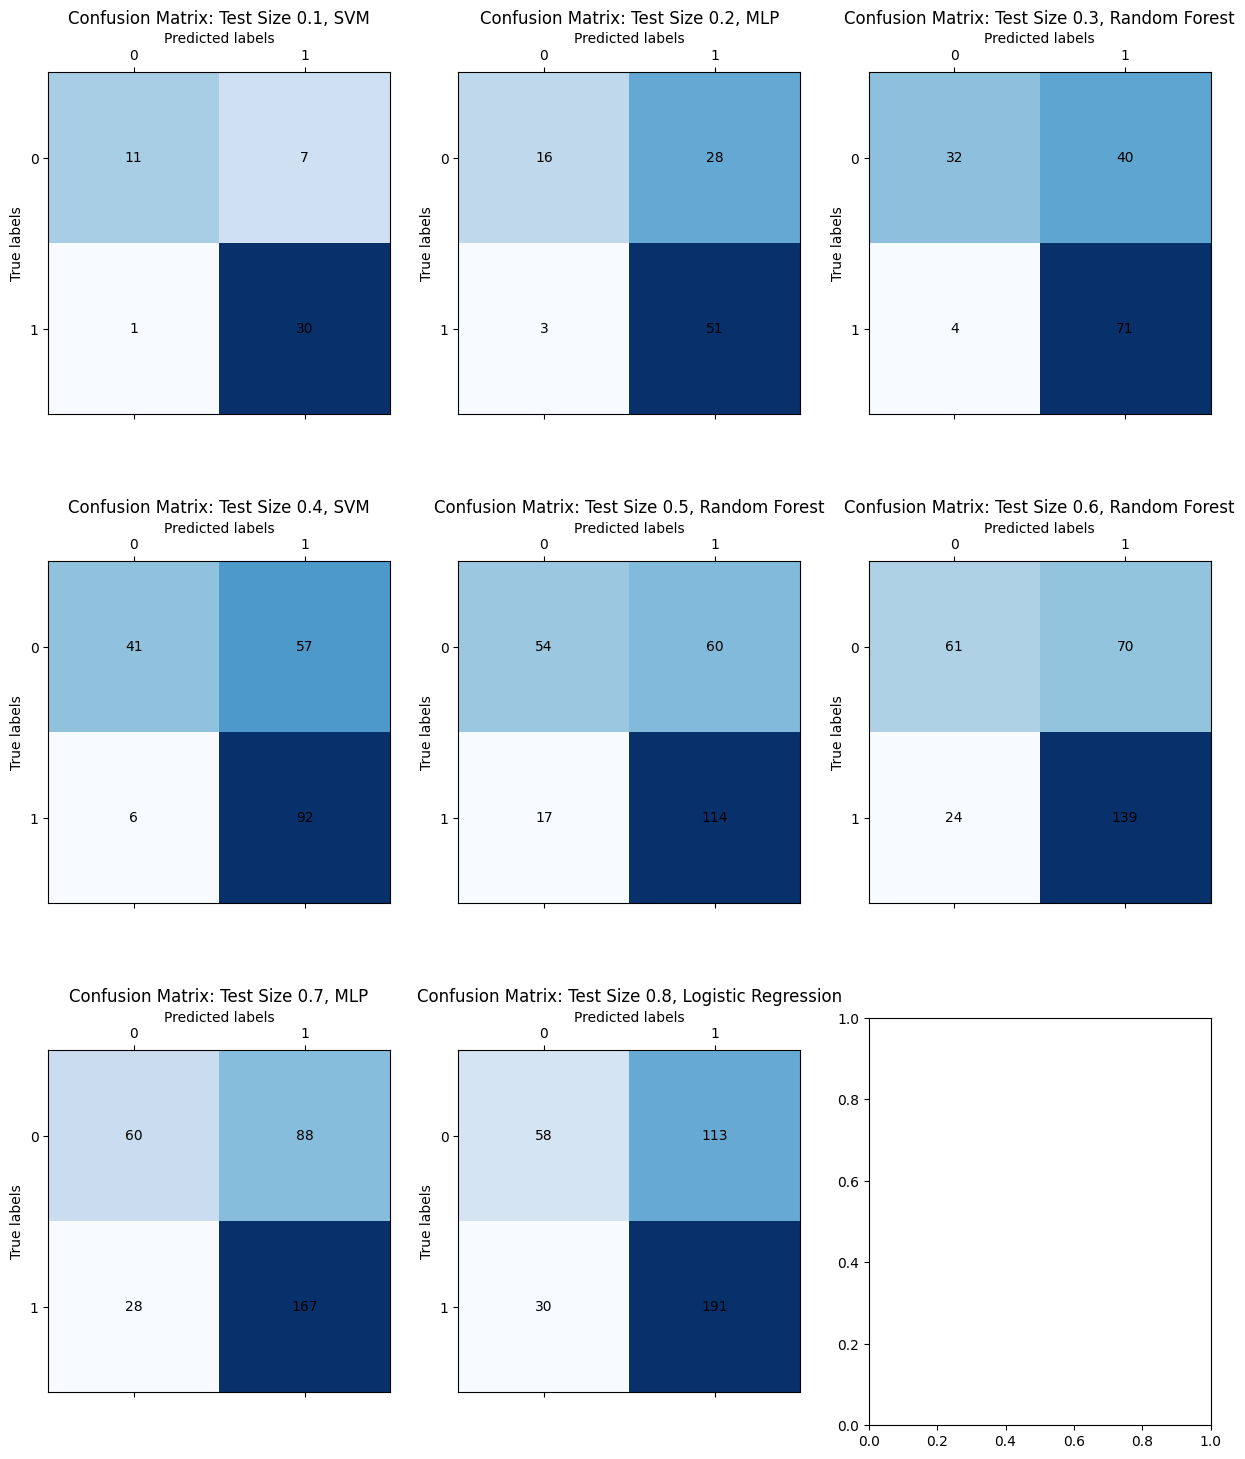

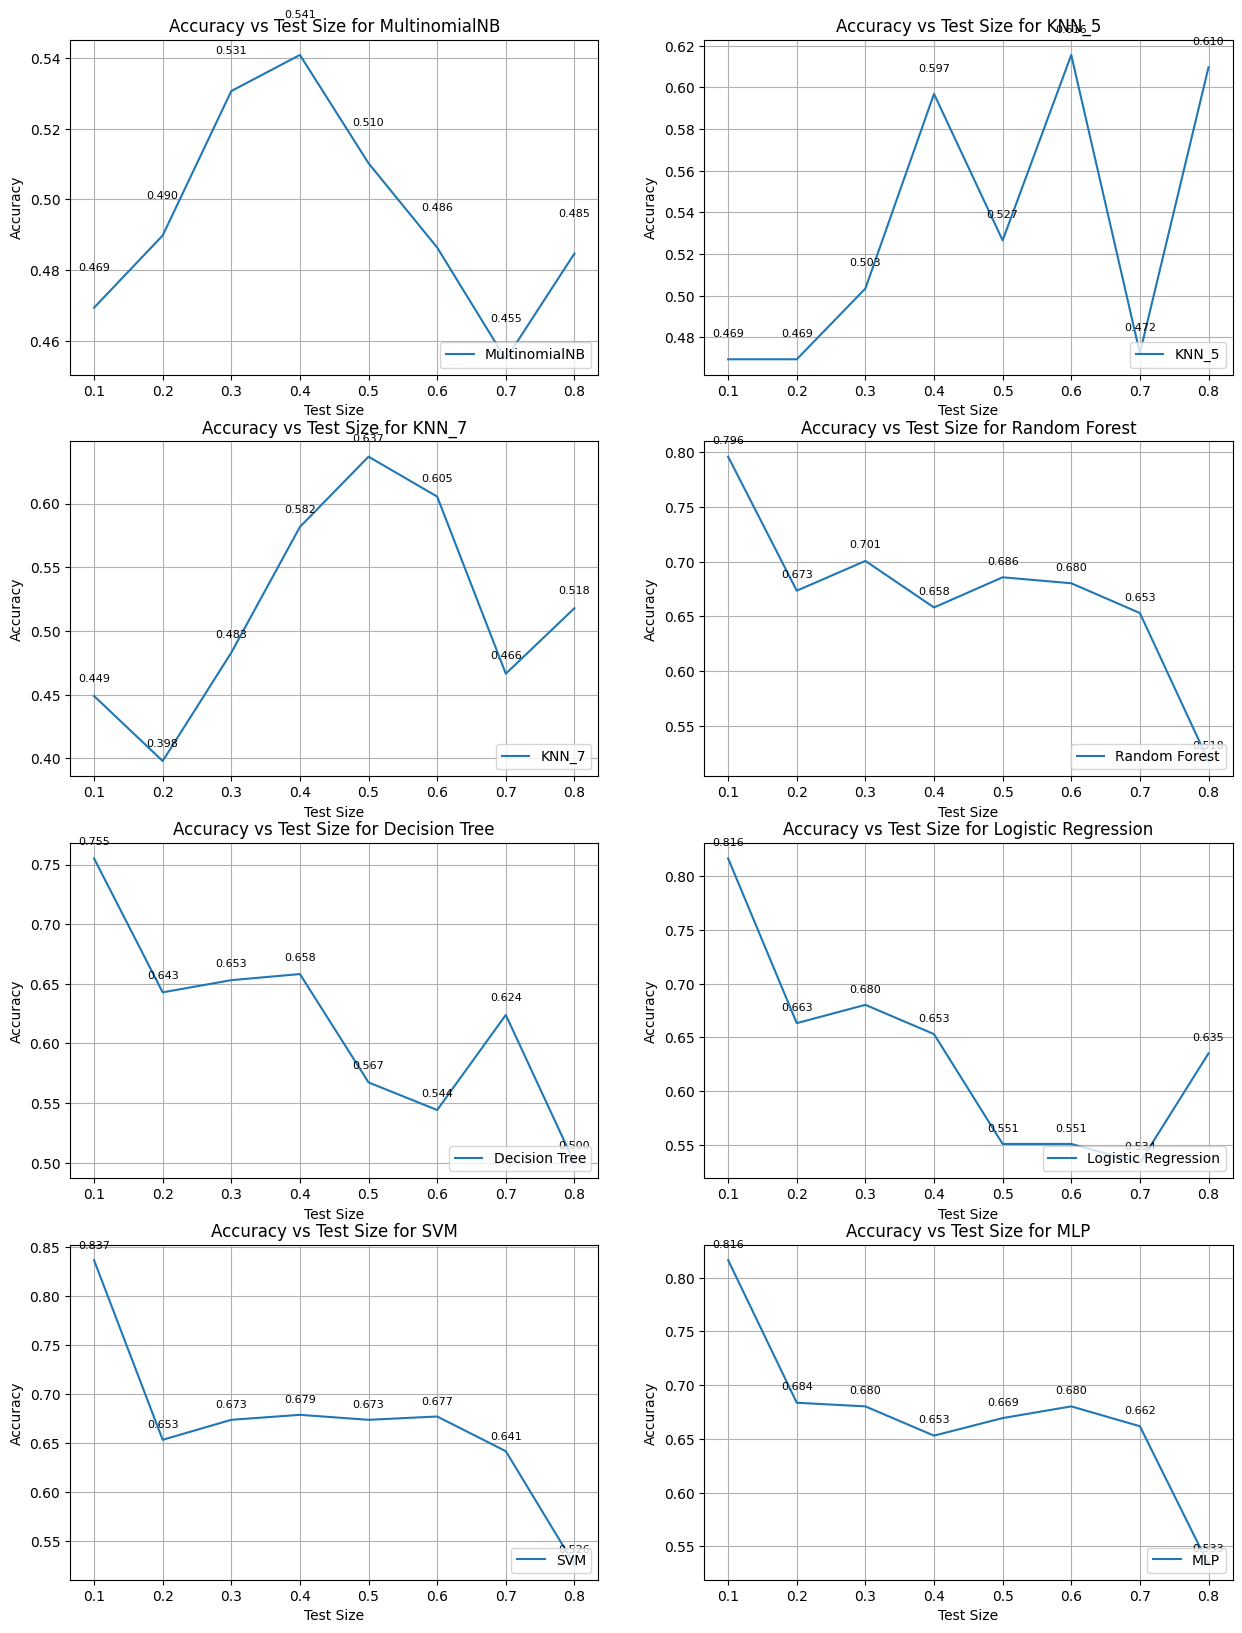

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics 
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
# from scipy.stats import mode
# from statistics import mode as stat_mode
import warnings
warnings.filterwarnings("ignore")

random_state = 71
test_sizes = np.arange(0.1, 0.9, 0.1)
SVD_n_components = 150

accuracies_Mnb = []
accuracies_knn_5 = []
accuracies_knn_7 = []
accuracies_rf = []
accuracies_dt = []
accuracies_lr = []
accuracies_svc = []
accuracies_mlp = []

models = {
    'MultinomialNB': GaussianNB(),
    'KNN_5': KNeighborsClassifier(n_neighbors=5),
    'KNN_7': KNeighborsClassifier(n_neighbors=7),
    'Random Forest': RandomForestClassifier(random_state=random_state, max_depth=10, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=random_state, max_depth=10, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=random_state, class_weight='balanced'),
    'SVM': SVC(random_state=random_state, class_weight='balanced'),
    'MLP': MLPClassifier(random_state=random_state, max_iter=1000)
    }

results = {}
best_results = {}
for test in test_sizes:
    print(f'Test ratio: {test}')
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= test, random_state=random_state)

    svd = TruncatedSVD(n_components=SVD_n_components)
    X_train = svd.fit_transform(X_train)
    X_test = svd.transform(X_test)
    print(f"PCA reduced the feature count from {X.shape[1]} to {X_train.shape[1]}")



    best_model = None
    best_accuracy = 0.0 

    for name, model in models.items():
        results[name] = {}
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        # print(f"{name} 測試比例：{1 - test}, Accuracy: {accuracy_score(y_test, y_pred)}")
        acc = accuracy_score(y_test, y_pred)
        # results[name][test] = {'Accuracy': acc, 'Confusion Matrix': confusion_matrix(y_test, y_pred)}
        if name == 'MultinomialNB':
            accuracies_Mnb.append(acc)
        elif name == 'KNN_5':
            accuracies_knn_5.append(acc)
        elif name == 'KNN_7':
            accuracies_knn_7.append(acc)
        elif name == 'Random Forest':
            accuracies_rf.append(acc)
        elif name == 'Decision Tree':
            accuracies_dt.append(acc)
        elif name == 'Logistic Regression':
            accuracies_lr.append(acc)
        elif name == 'SVM':
            accuracies_svc.append(acc)
        elif name == 'MLP': 
            accuracies_mlp.append(acc)
        
    

        if acc > best_accuracy:
            best_accuracy = acc
            best_model = name
            best_confusion_matrix = confusion_matrix(y_test, y_pred)
            best_y_test = y_test
            best_y_pred = y_pred
    best_results[test] = {'Best Model': best_model, 'Best Accuracy': best_accuracy, 'Confusion Matrix': best_confusion_matrix}
    print(f"\n====== {test} {best_model} ======")
    print(f"In test ratio {test}, the Best Model: {best_model} with Accuracy: {best_accuracy}")
    print("[Train] Classification Report:\n", classification_report(best_y_test, best_y_pred))
# print(results)


#畫出confusion matrix
def plot_confusion_matrix(cm, test, model_name, ax):
    ax.matshow(cm, cmap=plt.cm.Blues)
    ax.set_title(f'Confusion Matrix: Test Size {test:.1f}, {model_name}')
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.xaxis.set_label_position('top')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center')

fig, axs = plt.subplots(3, 3, figsize=(15, 18))
for ax, (test, best_results) in zip(axs.flatten(), best_results.items()):
    plot_confusion_matrix(best_results['Confusion Matrix'], test, best_results['Best Model'], ax)



#畫出每個模型在不同test size的準確率
results = {}
for k in models.keys():
    # print(k)
    # results[k] = {}
    if k == 'MultinomialNB':
            results[k] = dict(zip(test_sizes, accuracies_Mnb))
    elif k == 'KNN_5':
        results[k] = dict(zip(test_sizes, accuracies_knn_5))
    elif k == 'KNN_7':
        results[k] = dict(zip(test_sizes, accuracies_knn_7))
    elif k == 'Random Forest':
        results[k] = dict(zip(test_sizes, accuracies_rf))
    elif k == 'Decision Tree':
        results[k] = dict(zip(test_sizes, accuracies_dt))
    elif k == 'Logistic Regression':
        results[k] = dict(zip(test_sizes, accuracies_lr))
    elif k == 'SVM':
        results[k] = dict(zip(test_sizes, accuracies_svc))
    elif k == 'MLP': 
        results[k] = dict(zip(test_sizes, accuracies_mlp))


def plot_accuracy(test_size, accuracies, model_name, ax):
    sns.lineplot(x = test_size, y = accuracies, label=model_name, ax=ax)
    for x, y in zip(test_size, accuracies):
        ax.text(x, y + 0.01, f'{y:.3f}', ha='center', va='bottom', fontsize=8, color='black')
    ax.set_xlabel('Test Size')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy vs Test Size for {model_name}')
    ax.grid(True)
    ax.legend(loc='lower right')

fig, axs = plt.subplots(4, 2, figsize=(15, 20))
for ax, (model, result) in zip(axs.flatten(), results.items()):
    x_vals = list(result.keys())
    y_vals = list(result.values())
    plot_accuracy(x_vals, y_vals, model, ax)


tfidf模型建置

Test ratio: 0.1
PCA reduced the feature count from 658 to 150

====== 0.1 Random Forest ======
In test ratio 0.1, the Best Model: Random Forest with Accuracy: 0.8367346938775511
[Train] Classification Report:
               precision    recall  f1-score   support

        Down       0.92      0.61      0.73        18
          Up       0.81      0.97      0.88        31

    accuracy                           0.84        49
   macro avg       0.86      0.79      0.81        49
weighted avg       0.85      0.84      0.83        49

Test ratio: 0.2
PCA reduced the feature count from 658 to 150

====== 0.2 Decision Tree ======
In test ratio 0.2, the Best Model: Decision Tree with Accuracy: 0.7142857142857143
[Train] Classification Report:
               precision    recall  f1-score   support

        Down       0.79      0.50      0.61        44
          Up       0.69      0.89      0.77        54

    accuracy                           0.71        98
   macro avg       0.74      0.69  

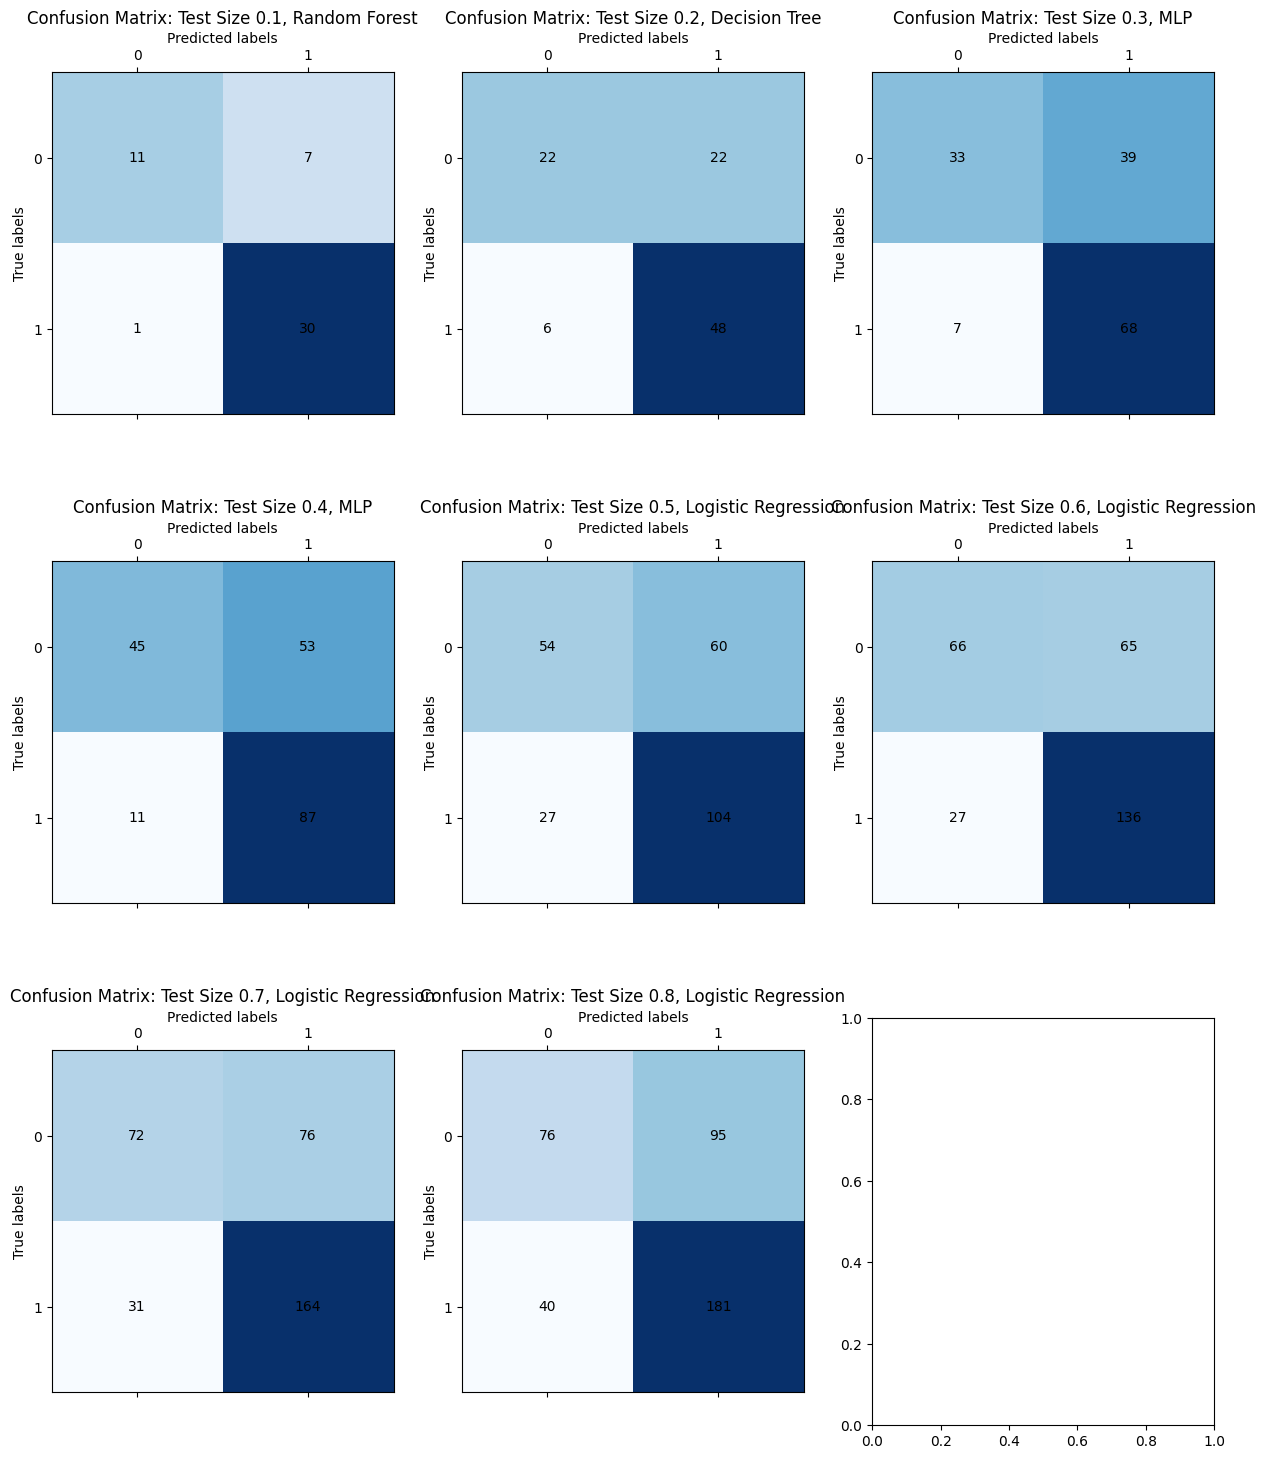

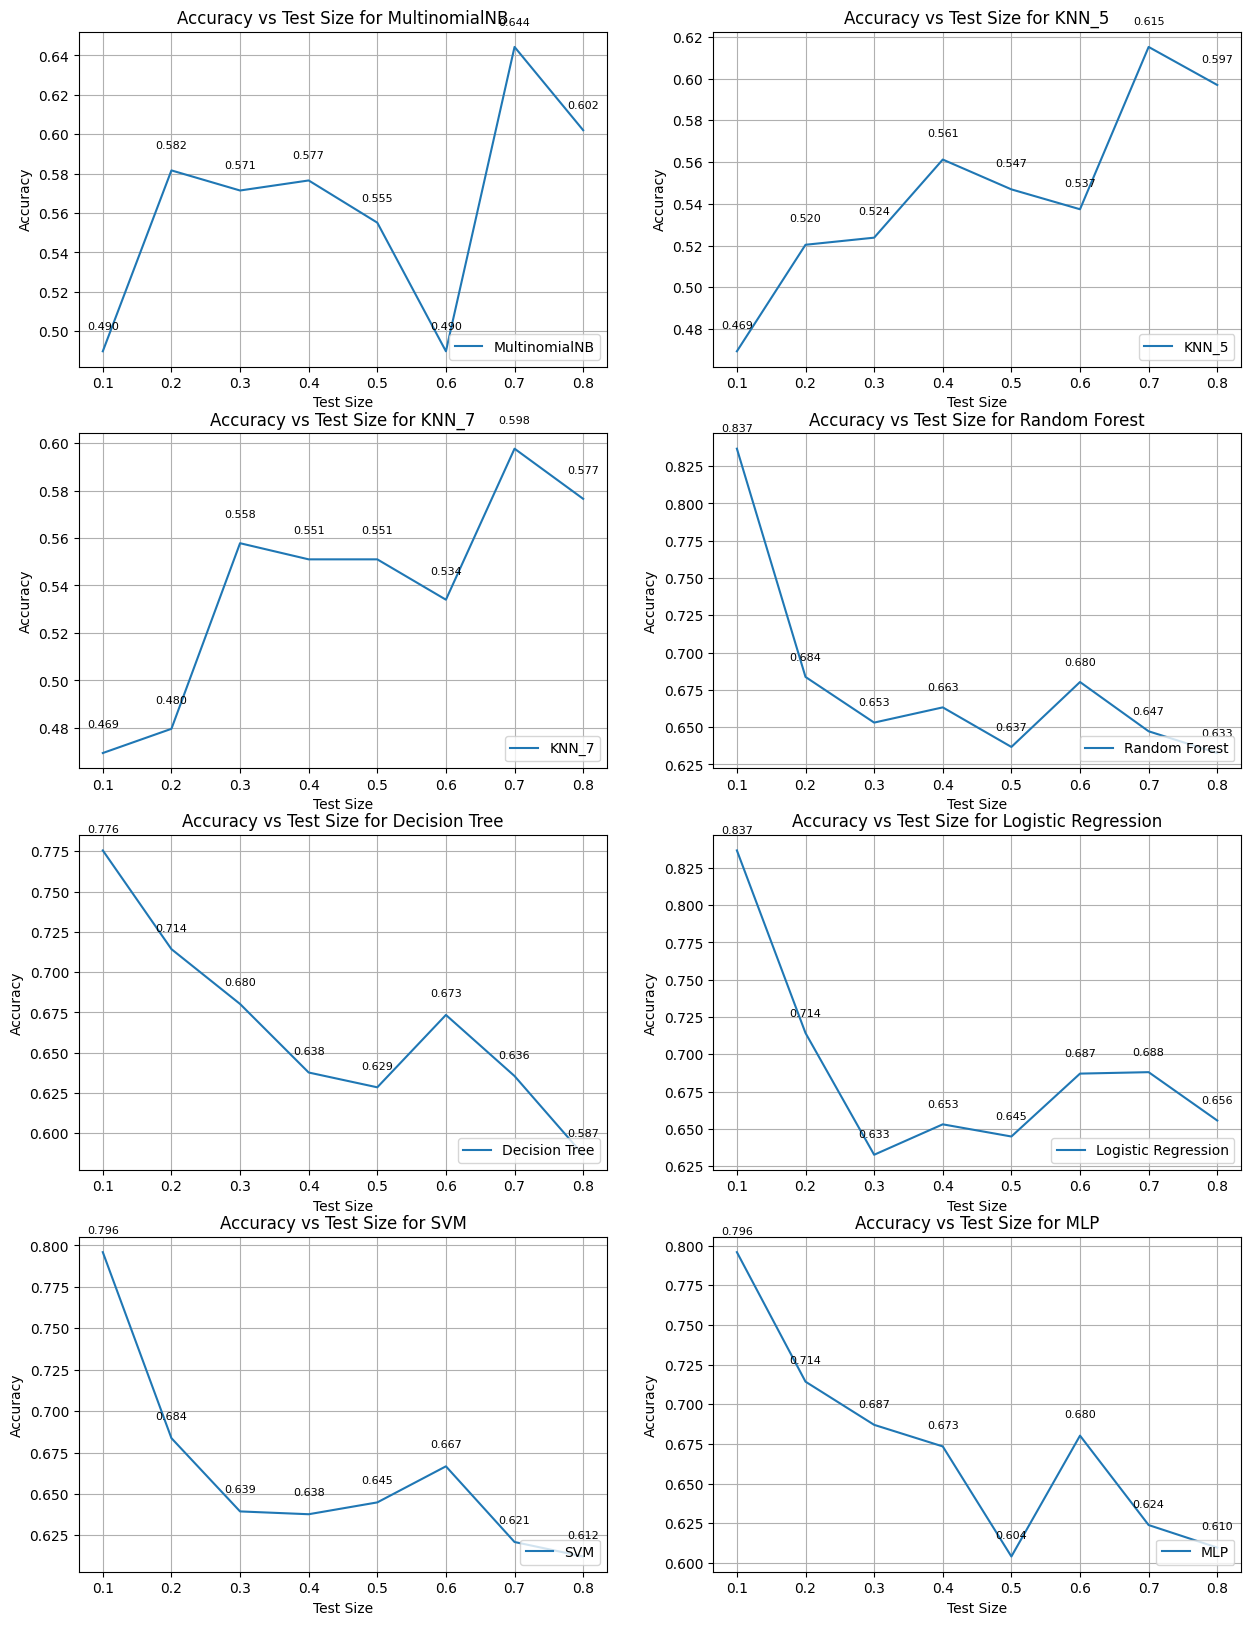

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics 
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
# from scipy.stats import mode
# from statistics import mode as stat_mode
import warnings
warnings.filterwarnings("ignore")

random_state = 71
test_sizes = np.arange(0.1, 0.9, 0.1)
SVD_n_components = 150

accuracies_Mnb = []
accuracies_knn_5 = []
accuracies_knn_7 = []
accuracies_rf = []
accuracies_dt = []
accuracies_lr = []
accuracies_svc = []
accuracies_mlp = []

models = {
    'MultinomialNB': GaussianNB(),
    'KNN_5': KNeighborsClassifier(n_neighbors=5),
    'KNN_7': KNeighborsClassifier(n_neighbors=7),
    'Random Forest': RandomForestClassifier(random_state=random_state, max_depth=10, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=random_state, max_depth=10, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=random_state, class_weight='balanced'),
    'SVM': SVC(random_state=random_state, class_weight='balanced'),
    'MLP': MLPClassifier(random_state=random_state, max_iter=1000)
    }

results = {}
best_results = {}
for test in test_sizes:
    print(f'Test ratio: {test}')
    X_train, X_test, y_train, y_test = train_test_split(tfidf_X, y, test_size= test, random_state=random_state)

    svd = TruncatedSVD(n_components=SVD_n_components)
    X_train = svd.fit_transform(X_train)
    X_test = svd.transform(X_test)
    print(f"PCA reduced the feature count from {X.shape[1]} to {X_train.shape[1]}")



    best_model = None
    best_accuracy = 0.0 

    for name, model in models.items():
        results[name] = {}
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        # print(f"{name} 測試比例：{1 - test}, Accuracy: {accuracy_score(y_test, y_pred)}")
        acc = accuracy_score(y_test, y_pred)
        # results[name][test] = {'Accuracy': acc, 'Confusion Matrix': confusion_matrix(y_test, y_pred)}
        if name == 'MultinomialNB':
            accuracies_Mnb.append(acc)
        elif name == 'KNN_5':
            accuracies_knn_5.append(acc)
        elif name == 'KNN_7':
            accuracies_knn_7.append(acc)
        elif name == 'Random Forest':
            accuracies_rf.append(acc)
        elif name == 'Decision Tree':
            accuracies_dt.append(acc)
        elif name == 'Logistic Regression':
            accuracies_lr.append(acc)
        elif name == 'SVM':
            accuracies_svc.append(acc)
        elif name == 'MLP': 
            accuracies_mlp.append(acc)
        
    

        if acc > best_accuracy:
            best_accuracy = acc
            best_model = name
            best_confusion_matrix = confusion_matrix(y_test, y_pred)
            best_y_test = y_test
            best_y_pred = y_pred
    best_results[test] = {'Best Model': best_model, 'Best Accuracy': best_accuracy, 'Confusion Matrix': best_confusion_matrix}
    print(f"\n====== {test} {best_model} ======")
    print(f"In test ratio {test}, the Best Model: {best_model} with Accuracy: {best_accuracy}")
    print("[Train] Classification Report:\n", classification_report(best_y_test, best_y_pred))
# print(results)


#畫出confusion matrix
def plot_confusion_matrix(cm, test, model_name, ax):
    ax.matshow(cm, cmap=plt.cm.Blues)
    ax.set_title(f'Confusion Matrix: Test Size {test:.1f}, {model_name}')
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.xaxis.set_label_position('top')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center')

fig, axs = plt.subplots(3, 3, figsize=(15, 18))
for ax, (test, best_results) in zip(axs.flatten(), best_results.items()):
    plot_confusion_matrix(best_results['Confusion Matrix'], test, best_results['Best Model'], ax)



#畫出每個模型在不同test size的準確率
results = {}
for k in models.keys():
    # print(k)
    # results[k] = {}
    if k == 'MultinomialNB':
            results[k] = dict(zip(test_sizes, accuracies_Mnb))
    elif k == 'KNN_5':
        results[k] = dict(zip(test_sizes, accuracies_knn_5))
    elif k == 'KNN_7':
        results[k] = dict(zip(test_sizes, accuracies_knn_7))
    elif k == 'Random Forest':
        results[k] = dict(zip(test_sizes, accuracies_rf))
    elif k == 'Decision Tree':
        results[k] = dict(zip(test_sizes, accuracies_dt))
    elif k == 'Logistic Regression':
        results[k] = dict(zip(test_sizes, accuracies_lr))
    elif k == 'SVM':
        results[k] = dict(zip(test_sizes, accuracies_svc))
    elif k == 'MLP': 
        results[k] = dict(zip(test_sizes, accuracies_mlp))


def plot_accuracy(test_size, accuracies, model_name, ax):
    sns.lineplot(x = test_size, y = accuracies, label=model_name, ax=ax)
    for x, y in zip(test_size, accuracies):
        ax.text(x, y + 0.01, f'{y:.3f}', ha='center', va='bottom', fontsize=8, color='black')
    ax.set_xlabel('Test Size')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy vs Test Size for {model_name}')
    ax.grid(True)
    ax.legend(loc='lower right')

fig, axs = plt.subplots(4, 2, figsize=(15, 20))
for ax, (model, result) in zip(axs.flatten(), results.items()):
    x_vals = list(result.keys())
    y_vals = list(result.values())
    plot_accuracy(x_vals, y_vals, model, ax)


#ALL模型建制

Test ratio: 0.1
PCA reduced the feature count from 658 to 200

====== 0.1 Random Forest ======
In test ratio 0.1, the Best Model: Random Forest with Accuracy: 0.8163265306122449
[Train] Classification Report:
               precision    recall  f1-score   support

        Down       0.71      0.83      0.77        18
          Up       0.89      0.81      0.85        31

    accuracy                           0.82        49
   macro avg       0.80      0.82      0.81        49
weighted avg       0.83      0.82      0.82        49

Test ratio: 0.2
PCA reduced the feature count from 658 to 200

====== 0.2 Logistic Regression ======
In test ratio 0.2, the Best Model: Logistic Regression with Accuracy: 0.6938775510204082
[Train] Classification Report:
               precision    recall  f1-score   support

        Down       0.64      0.73      0.68        44
          Up       0.75      0.67      0.71        54

    accuracy                           0.69        98
   macro avg       0.70

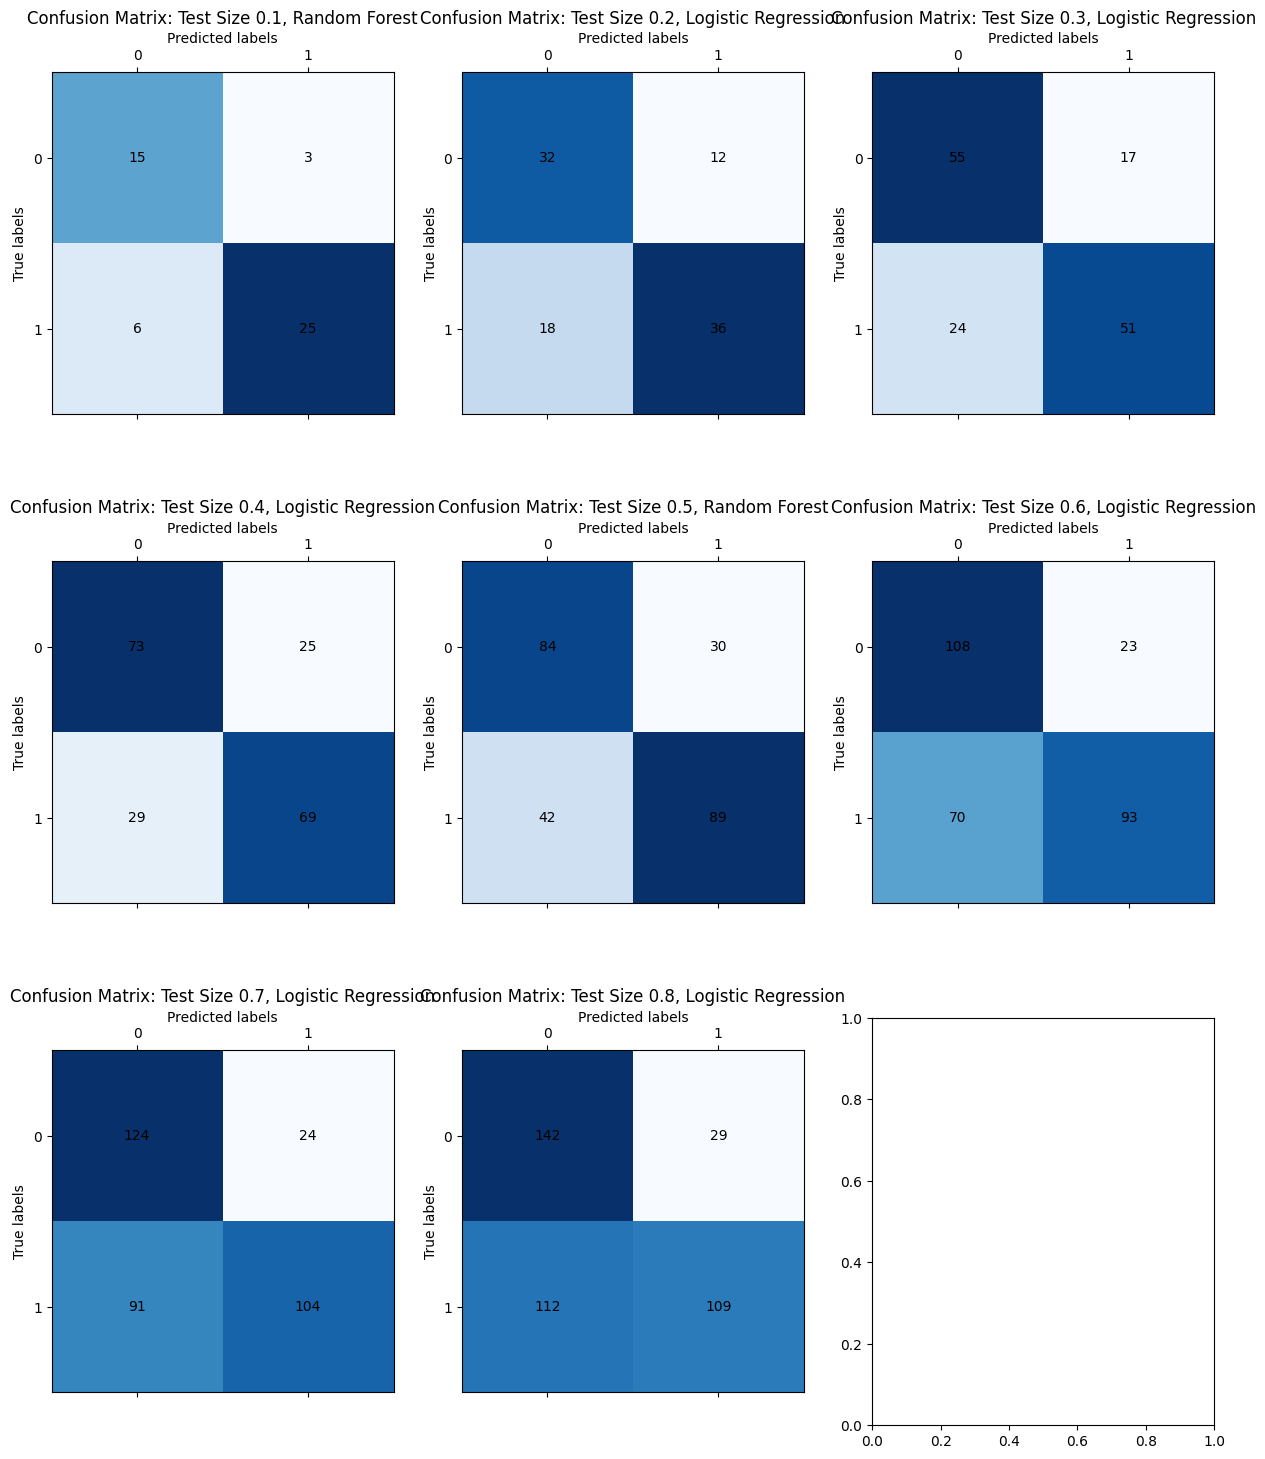

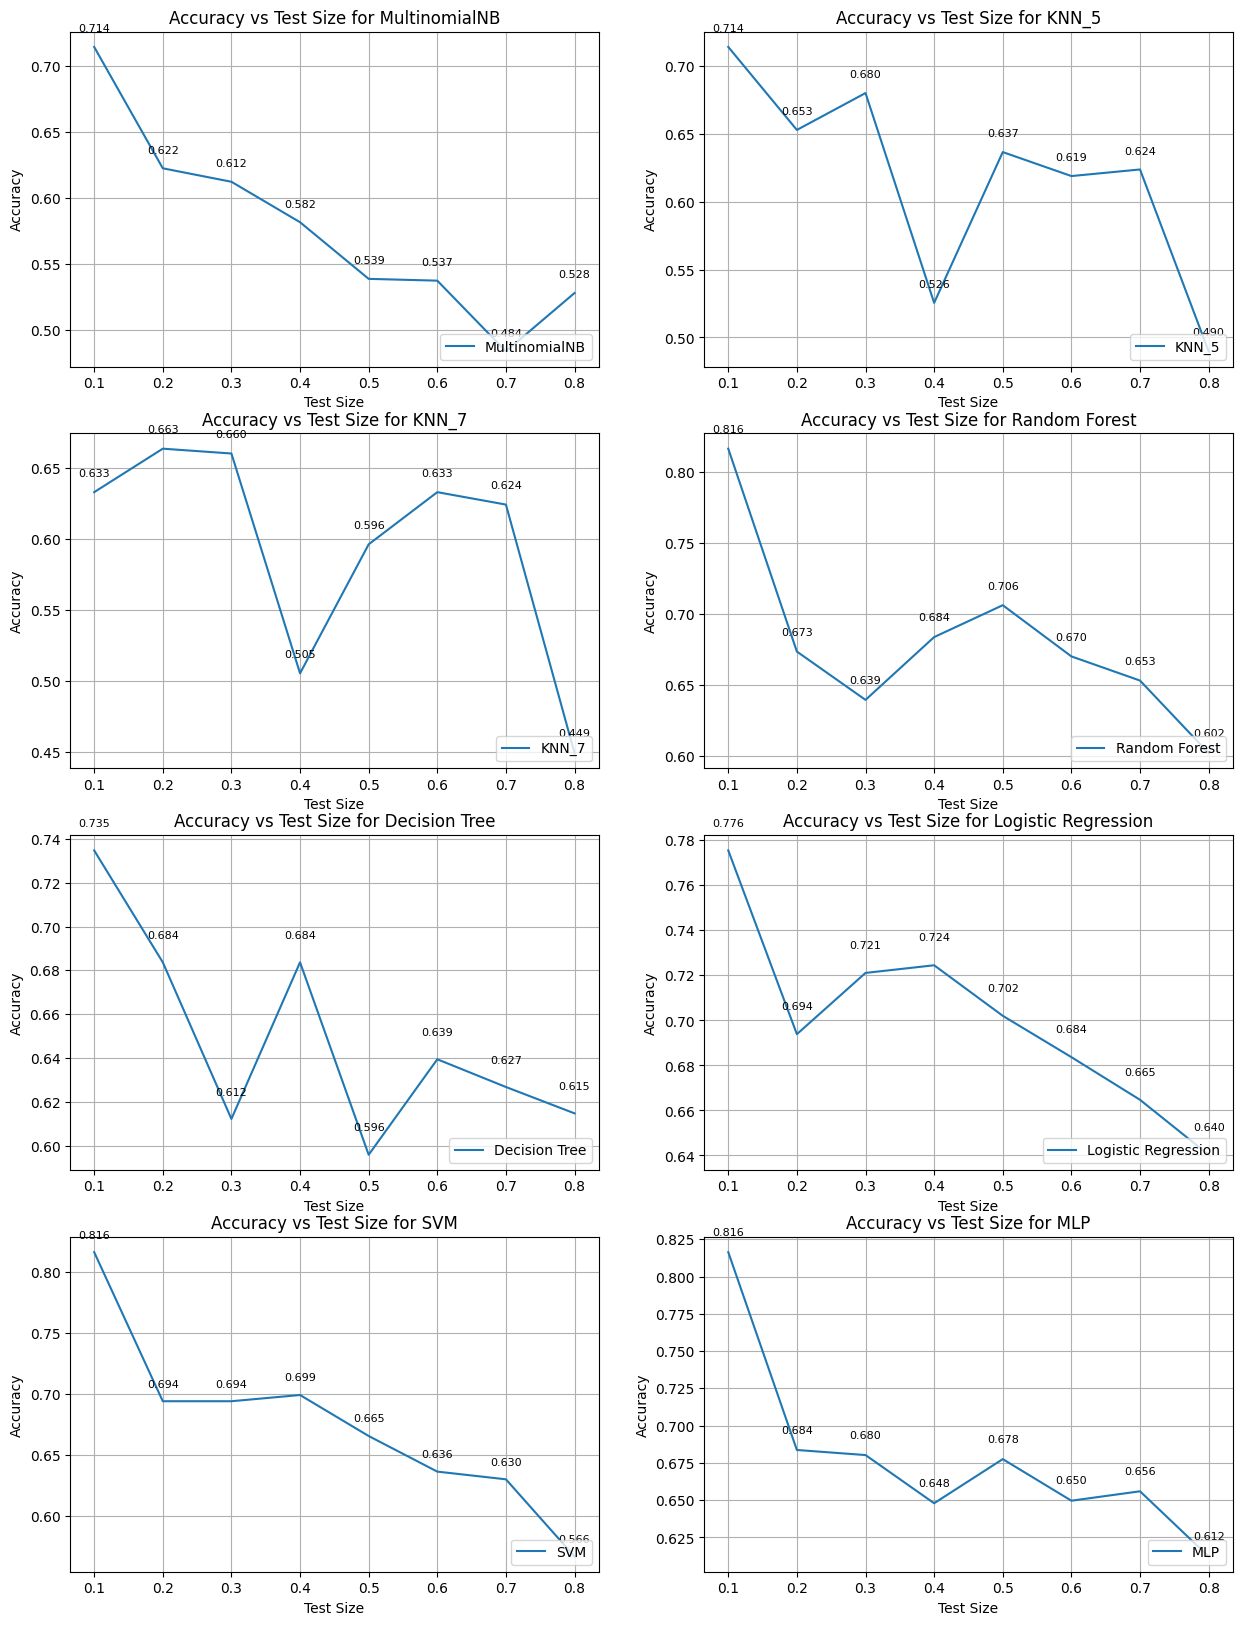

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics 
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
# from scipy.stats import mode
# from statistics import mode as stat_mode
import warnings
warnings.filterwarnings("ignore")

random_state = 71
test_sizes = np.arange(0.1, 0.9, 0.1)
SVD_n_components = 200

accuracies_Mnb = []
accuracies_knn_5 = []
accuracies_knn_7 = []
accuracies_rf = []
accuracies_dt = []
accuracies_lr = []
accuracies_svc = []
accuracies_mlp = []

models = {
    'MultinomialNB': GaussianNB(),
    'KNN_5': KNeighborsClassifier(n_neighbors=5),
    'KNN_7': KNeighborsClassifier(n_neighbors=7),
    'Random Forest': RandomForestClassifier(random_state=random_state, max_depth=10, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=random_state, max_depth=10, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=random_state, class_weight='balanced'),
    'SVM': SVC(random_state=random_state, class_weight='balanced'),
    'MLP': MLPClassifier(random_state=random_state, max_iter=1000)
    }

results = {}
best_results = {}
for test in test_sizes:
    print(f'Test ratio: {test}')
    X_train, X_test, y_train, y_test = train_test_split(All_X, y, test_size= test, random_state=random_state)

    svd = TruncatedSVD(n_components=SVD_n_components)
    X_train = svd.fit_transform(X_train)
    X_test = svd.transform(X_test)
    print(f"PCA reduced the feature count from {X.shape[1]} to {X_train.shape[1]}")



    best_model = None
    best_accuracy = 0.0 

    for name, model in models.items():
        results[name] = {}
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        # print(f"{name} 測試比例：{1 - test}, Accuracy: {accuracy_score(y_test, y_pred)}")
        acc = accuracy_score(y_test, y_pred)
        # results[name][test] = {'Accuracy': acc, 'Confusion Matrix': confusion_matrix(y_test, y_pred)}
        if name == 'MultinomialNB':
            accuracies_Mnb.append(acc)
        elif name == 'KNN_5':
            accuracies_knn_5.append(acc)
        elif name == 'KNN_7':
            accuracies_knn_7.append(acc)
        elif name == 'Random Forest':
            accuracies_rf.append(acc)
        elif name == 'Decision Tree':
            accuracies_dt.append(acc)
        elif name == 'Logistic Regression':
            accuracies_lr.append(acc)
        elif name == 'SVM':
            accuracies_svc.append(acc)
        elif name == 'MLP': 
            accuracies_mlp.append(acc)
        
    

        if acc > best_accuracy:
            best_accuracy = acc
            best_model = name
            best_confusion_matrix = confusion_matrix(y_test, y_pred)
            best_y_test = y_test
            best_y_pred = y_pred
    best_results[test] = {'Best Model': best_model, 'Best Accuracy': best_accuracy, 'Confusion Matrix': best_confusion_matrix}
    print(f"\n====== {test} {best_model} ======")
    print(f"In test ratio {test}, the Best Model: {best_model} with Accuracy: {best_accuracy}")
    print("[Train] Classification Report:\n", classification_report(best_y_test, best_y_pred))
# print(results)


#畫出confusion matrix
def plot_confusion_matrix(cm, test, model_name, ax):
    ax.matshow(cm, cmap=plt.cm.Blues)
    ax.set_title(f'Confusion Matrix: Test Size {test:.1f}, {model_name}')
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.xaxis.set_label_position('top')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center')

fig, axs = plt.subplots(3, 3, figsize=(15, 18))
for ax, (test, best_results) in zip(axs.flatten(), best_results.items()):
    plot_confusion_matrix(best_results['Confusion Matrix'], test, best_results['Best Model'], ax)



#畫出每個模型在不同test size的準確率
results = {}
for k in models.keys():
    # print(k)
    # results[k] = {}
    if k == 'MultinomialNB':
            results[k] = dict(zip(test_sizes, accuracies_Mnb))
    elif k == 'KNN_5':
        results[k] = dict(zip(test_sizes, accuracies_knn_5))
    elif k == 'KNN_7':
        results[k] = dict(zip(test_sizes, accuracies_knn_7))
    elif k == 'Random Forest':
        results[k] = dict(zip(test_sizes, accuracies_rf))
    elif k == 'Decision Tree':
        results[k] = dict(zip(test_sizes, accuracies_dt))
    elif k == 'Logistic Regression':
        results[k] = dict(zip(test_sizes, accuracies_lr))
    elif k == 'SVM':
        results[k] = dict(zip(test_sizes, accuracies_svc))
    elif k == 'MLP': 
        results[k] = dict(zip(test_sizes, accuracies_mlp))


def plot_accuracy(test_size, accuracies, model_name, ax):
    sns.lineplot(x = test_size, y = accuracies, label=model_name, ax=ax)
    for x, y in zip(test_size, accuracies):
        ax.text(x, y + 0.01, f'{y:.3f}', ha='center', va='bottom', fontsize=8, color='black')
    ax.set_xlabel('Test Size')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy vs Test Size for {model_name}')
    ax.grid(True)
    ax.legend(loc='lower right')

fig, axs = plt.subplots(4, 2, figsize=(15, 20))
for ax, (model, result) in zip(axs.flatten(), results.items()):
    x_vals = list(result.keys())
    y_vals = list(result.values())
    plot_accuracy(x_vals, y_vals, model, ax)


In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.1, random_state=random_state)

SVD_n_components = 150
svd = TruncatedSVD(n_components=SVD_n_components)
X_train = svd.fit_transform(X_train)
X_test = svd.transform(X_test)

svc_1 = SVC(random_state=random_state, class_weight='balanced')

svc_1.fit(X_train, y_train)
y_pred = svc_1.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print(f"In test ratio 0.1, the Best Model: with Accuracy: {acc}")
print("[Train] Classification Report:\n", classification_report(y_test, y_pred))

import joblib
joblib.dump(svc_1, 'svc_1_model.pkl')
joblib.dump(svd, 'svd1_model.pkl')

print("Model saved successfully!")

In test ratio 0.1, the Best Model: with Accuracy: 0.8367346938775511
[Train] Classification Report:
               precision    recall  f1-score   support

        Down       0.92      0.61      0.73        18
          Up       0.81      0.97      0.88        31

    accuracy                           0.84        49
   macro avg       0.86      0.79      0.81        49
weighted avg       0.85      0.84      0.83        49

Model saved successfully!


In [46]:
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(tfidf_X, y, test_size= 0.1, random_state=random_state)

SVD_n_components = 150
svd = TruncatedSVD(n_components=SVD_n_components)
X_train_tfidf = svd.fit_transform(X_train_tfidf)
X_test_tfidf = svd.transform(X_test_tfidf)

LRtfidf = LogisticRegression(max_iter=1000, random_state=random_state, class_weight='balanced')
LRtfidf.fit(X_train_tfidf, y_train_tfidf)
y_pred_tfidf = LRtfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test_tfidf, y_pred_tfidf)

print(f"In test ratio 0.1, the Logistic Regression Model: with Accuracy: {acc_tfidf}")
print("[Train] Classification Report:\n", classification_report(y_test_tfidf, y_pred_tfidf))

import joblib

# Save the trained LRtfidf model to a file
joblib.dump(LRtfidf, 'LRtfidf_model.pkl')
joblib.dump(svd, 'svd_model.pkl')

print("Model saved successfully!")



In test ratio 0.1, the Logistic Regression Model: with Accuracy: 0.8367346938775511
[Train] Classification Report:
               precision    recall  f1-score   support

        Down       1.00      0.56      0.71        18
          Up       0.79      1.00      0.89        31

    accuracy                           0.84        49
   macro avg       0.90      0.78      0.80        49
weighted avg       0.87      0.84      0.82        49

Model saved successfully!


In [47]:
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(All_X, y, test_size= 0.1, random_state=random_state)
SVD_n_components = 200
svd = TruncatedSVD(n_components=SVD_n_components)
X_train_all = svd.fit_transform(X_train_all)
X_test_all = svd.transform(X_test_all)

svc_all = SVC(random_state=random_state, class_weight='balanced')

svc_all.fit(X_train_all, y_train_all)
y_pred_all = svc_all.predict(X_test_all)

acc_all = accuracy_score(y_test_all, y_pred_all)

print(f"In test ratio 0.1, the SVC Model: with Accuracy: {acc_all}")
print("[Train] Classification Report:\n", classification_report(y_test_all, y_pred_all))

joblib.dump(svc_all, 'svc_all_model.pkl')
joblib.dump(svd, 'svd3_model.pkl')

print("Model saved successfully!")

In test ratio 0.1, the SVC Model: with Accuracy: 0.8163265306122449
[Train] Classification Report:
               precision    recall  f1-score   support

        Down       0.67      1.00      0.80        18
          Up       1.00      0.71      0.83        31

    accuracy                           0.82        49
   macro avg       0.83      0.85      0.82        49
weighted avg       0.88      0.82      0.82        49

Model saved successfully!


開始進行後側

In [48]:
tf_counter2722 = Counter()
df_counter2722 = Counter()

f = open('2722_news.csv', newline='', encoding='utf-8')
rows = csv.reader(f, delimiter=',')
i = 0
for row in rows:
    # print(row[1], row[2])
    i = i + 1
    if i > 1:
        query = row[1]+' ' + row[2]
        df_temp = Counter()
        sentence_list = utils.short_sentence(query)
        for item in sentence_list:
            word_cut = monpa.cut(item)
            for term in word_cut:
                term = term.strip()
                if (len(term) > 1):
                    tf_counter2722[term] += 1
                    if (df_temp[term] == 0):
                        df_temp[term] = 1
        df_counter2722 += df_temp

f.close()

In [49]:
#1200
tf_counter2722_1 = tf_counter2722.most_common(1200)
#1400
tf_counter2722_tfidf = tf_counter2722.most_common(1400)
#1500
tf_counter2722_all = tf_counter2722.most_common(1500)

In [50]:
tf_counter2722_all

[('指數', 1417),
 ('台股', 1321),
 ('股價', 1032),
 ('觀光', 930),
 ('夏都', 906),
 ('上漲', 807),
 ('漲幅', 739),
 ('表現', 707),
 ('族群', 687),
 ('漲停', 683),
 ('今日', 611),
 ('台積電', 580),
 ('類股', 570),
 ('下跌', 569),
 ('外資', 546),
 ('公司', 538),
 ('市場', 523),
 ('法人', 503),
 ('震盪', 485),
 ('AI', 452),
 ('2722', 450),
 ('TW', 422),
 ('持續', 422),
 ('營收', 415),
 ('今年', 407),
 ('寒舍', 401),
 ('台北', 401),
 ('美股', 391),
 ('大漲', 389),
 ('電子', 381),
 ('終場', 379),
 ('KY', 372),
 ('跌幅', 372),
 ('美國', 333),
 ('早盤', 331),
 ('新高', 329),
 ('交易', 328),
 ('雲品', 328),
 ('買超', 320),
 ('觀光股', 315),
 ('股市', 309),
 ('10', 304),
 ('強勢', 303),
 ('旅遊', 302),
 ('資金', 294),
 ('聯發科', 291),
 ('預期', 281),
 ('帶動', 276),
 ('投資', 272),
 ('加權', 270),
 ('題材', 270),
 ('鳳凰', 269),
 ('表示', 265),
 ('超過', 264),
 ('加上', 263),
 ('台灣', 260),
 ('獲利', 256),
 ('BR', 256),
 ('今天', 253),
 ('收盤', 249),
 ('相關', 248),
 ('飯店', 244),
 ('成交量', 240),
 ('大盤', 237),
 ('概念股', 233),
 ('以上', 230),
 ('鴻海', 229),
 ('其中', 225),
 ('方面', 224),
 ('走高', 223),
 ('個股', 22

In [51]:
f = open('total_1.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f)
for term in tf_counter2722.most_common(1200):
  writer.writerow(term)
f.close()

f = open('total_2.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f)
for term in tf_counter2722.most_common(1400):
  writer.writerow(term)
f.close()

f = open('total_3.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f)
for term in tf_counter2722.most_common(1500):
  writer.writerow(term)
f.close()

In [52]:
Backtest_term =dict()
num = 0
f = open('total_1.csv', newline='', encoding='utf-8')
rows = csv.reader(f, delimiter=',')
for row in rows:
  if row[0] not in All_up:
    Backtest_term[row[0]]=num
    num+=1
f.close()

Backtest_term_tfidf =dict()
num = 0
f = open('total_2.csv', newline='', encoding='utf-8')
rows = csv.reader(f, delimiter=',')
for row in rows:
  if row[0] not in All_up:
    Backtest_term_tfidf[row[0]]=num
    num+=1
f.close()

Backtest_term_all =dict()
num = 0
f = open('total_3.csv', newline='', encoding='utf-8')
rows = csv.reader(f, delimiter=',')
for row in rows:
  if row[0] not in All_up:
    Backtest_term_all[row[0]]=num
    num+=1
f.close()

In [53]:
data = pd.read_csv('2722_news.csv')
data

,post_time,title,content
0,2023-01-17,虎年封關電子熄火 航運觀光撐場 價跌量縮14900點震盪整理,台股今 (17) 日進行虎年封關交易，大盤多空勢力在平盤附近拉扯，權王台積電 (2330-T...
1,2023-02-09,春天來了...王品、新天地營收年增兩位數 雄獅年增近6倍、現增申購抽中賺2.8萬,受惠政府解除組團禁令，加上春節十天連假效應，觀光需求活絡帶動旅行社1月營收增長。（攝影／葉佳...
2,2023-02-15,〈台股盤後〉台積重挫 大跌221點收15432點 摜破10日線,股神巴菲特旗下投資公司波克夏重砍台積電 ADR，減持幅度高達 86%，台積電現貨今 (15)...
3,2023-02-20,台股反彈站回15500點 投信連3買 三大法人賣超19.76億元,台股今 (20) 日開低走高，隨著電子權值股止跌回穩，金融股強勢走揚，加上觀光百貨、車電等中...
4,2023-02-22,〈台股盤中〉普丁搗亂電金臉綠 大盤失守月線跌破15400點,美股四大指數重挫，台股今 (22) 日也跟著臉綠，權王台積電 (2330-TW) 帶頭領跌，...
...,...,...,...
678,2024-11-20,[創作] Baby Shark(夏都),https://youtu.be/XqZsoesa55w 突然有一咪咪靈感(? ====...
679,2025-01-09,[新聞] 慘！墾丁驚傳3家飯店將熄燈 觀光業再受,原文標題： 慘！墾丁驚傳3家飯店將熄燈 觀光業再受重擊 原文連結： https://n...
680,2025-01-14,[情報] 2722 夏都12月自結,標題： 2722 夏都12月自結 來源： 公開資訊觀測站 網址： https://...
681,2025-01-17,[閒聊] 2025/01/17 盤後閒聊,台 股 23148.08 ▲122.98 (+0.53%) 3203.17億 台指02 23...


In [54]:
result2722 = list()
f = open('2722_news.csv', newline='', encoding='utf-8')
rows = csv.reader(f, delimiter=',')

i=0
for row in rows:
  i=i+1 

  if(i>1): 
    query=row[0]+' '+row[1]
    str=''
    sentence_list = utils.short_sentence(query)
    for item in sentence_list:
      result_cut = monpa.cut(item)
      for term in result_cut:
        term=term.strip()
        if(len(term)>1):
           str=str+' '+term
    print(i, str)
    result2722.append(str)
    
f.close()
result2722

f = open('result2722_ok.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(f) 
for str in result2722:
  writer.writerow([str])
f.close()


total_content=list()

f = open('result2722_ok.csv', newline='', encoding='utf-8')
rows = csv.reader(f, delimiter=',')
for row in rows: 
  total_content.append(row[0])
f.close()

2  2023 01 17 虎年 封關 電子 熄火 航運 觀光 撐場 跌量 14900 震盪 整理
3  2023 02 09 春天 ... 王品 新天地 營收 位數 雄獅 現增 申購 抽中 2.8萬
4  2023 02 15 台股 台積 重挫 大跌 221 15432 摜破 10
5  2023 02 20 台股 反彈 站回 15500 投信 法人 19.76
6  2023 02 22 台股 普丁 搗亂 電金 大盤 失守 月線 跌破 15400
7  2023 02 22 焦點股 觀光 族群 聯袂 亮燈 漲停 家數 大盤 4成
8  2023 02 22 美股 重挫 科技 領跌 台股 早盤 217 新聞
9  2023 02 23 台積電 回穩 運輸 觀光 強攻 台股 200
10  2023 02 23 台股 200 台積電 大漲 14
11  2023 03 02 速報 觀光類 指數 類股 表現 強勁 漲幅 3.9 成交額 19.90
12  2023 03 02 台股 早盤 40 航運 亮眼 觀光
13  2023 03 02 美股 收黑 台股 走低 發現 觀光股 受惠 漲停
14  2023 03 02 台股 民視 收盤 翻紅 專家 留意
15  2023 03 07 電金 點火 台股 成功站 15800
16  2023 03 14 資金 提款 走人 電金 傳氣 台股 大跌 170
17  2023 03 17 台股 收盤 台積電 大漲 13 518 台股 231 15452 站上 五日線
18  2023 03 17 台股 大漲 站上 15400 外資 終止 法人 買超 125.4
19  2023 03 20 台股 金腿 壓抑 多頭 指數 15400 保衛戰
20  2023 03 20 台股 收盤 電金腿 台股 32 15419 量能 急凍 1896億
21  2023 03 20 台股 小跌 守穩 15400 外資 轉賣 法人 31億
22  2023 03 29 台股 漲幅 收斂 收斂 觀光 族群 散熱 雙雄 逆勢 強漲
23  2023 03 29 美股 收黑 台股 逆勢 指數 漲破 1萬5800
24  2023 04 19 觀光股 勁揚 王品 六角 飆漲
25  2023 04 21 台股 電子 傳產 熄火 104 15602 周線 

In [55]:
Backtest_term

{'TW': 0,
 '早盤': 1,
 '交易': 2,
 '買超': 3,
 '旅遊': 4,
 '獲利': 5,
 'BR': 6,
 '今天': 7,
 '數據': 8,
 '去年': 9,
 '兩岸': 10,
 '航空': 11,
 '走勢': 12,
 '股東會': 13,
 '成長': 14,
 '不過': 15,
 '來到': 16,
 '行情': 17,
 '權值股': 18,
 '公布': 19,
 '證券': 20,
 '同步': 21,
 '營運': 22,
 '以及': 23,
 '反彈': 24,
 '相對': 25,
 '日期': 26,
 '資訊': 27,
 '短線': 28,
 '亮燈': 29,
 '財報': 30,
 '價格': 31,
 '金額': 32,
 '美元': 33,
 '受惠': 34,
 '包括': 35,
 '事項': 36,
 '航運': 37,
 '賣壓': 38,
 '公告': 39,
 '近期': 40,
 '開盤': 41,
 '自營商': 42,
 '資料': 43,
 '可望': 44,
 '買盤': 45,
 '走揚': 46,
 '關卡': 47,
 '合併': 48,
 '維持': 49,
 '翻紅': 50,
 '升息': 51,
 '以來': 52,
 '月線': 53,
 '綠能': 54,
 '召開': 55,
 '2454': 56,
 '6月': 57,
 '歷史': 58,
 '留意': 59,
 '股票': 60,
 '五福': 61,
 '盈餘': 62,
 '旺季': 63,
 '收在': 64,
 '勁揚': 65,
 '漲勢': 66,
 '高檔': 67,
 '成交': 68,
 '需求': 69,
 '高點': 70,
 '適用': 71,
 '整理': 72,
 '開低': 73,
 '機會': 74,
 '翻黑': 75,
 '16': 76,
 '雙雄': 77,
 '華航': 78,
 'IC': 79,
 '聯準會': 80,
 '5月': 81,
 '觀察': 82,
 '燦星旅': 83,
 '殖利率': 84,
 '建議': 85,
 '3月': 86,
 '突破': 87,
 '新台幣': 88,
 '明年': 89,
 '9.9': 90,

In [56]:
vectorizer_1 = TfidfVectorizer(vocabulary=Backtest_term, use_idf=True, smooth_idf=True)
X_1 = vectorizer_1.fit_transform(total_content)
sparse.save_npz('2722_X1model.npz', X_1)
pd.DataFrame(X_1.toarray(),columns=Backtest_term) 

vectorizer_2 = TfidfVectorizer(vocabulary=Backtest_term_tfidf, use_idf=True, smooth_idf=True)
X_2 = vectorizer_2.fit_transform(total_content)
sparse.save_npz('2722_X2model.npz', X_2)
pd.DataFrame(X_2.toarray(),columns=Backtest_term_tfidf)

vectorizer_3 = TfidfVectorizer(vocabulary=Backtest_term_all, use_idf=True, smooth_idf=True)
X_3 = vectorizer_3.fit_transform(total_content)
sparse.save_npz('2722_X3model.npz', X_3)
pd.DataFrame(X_3.toarray(),columns=Backtest_term_all)

,TW,早盤,交易,買超,旅遊,獲利,BR,今天,數據,去年,...,6531,興櫃,0.9,志信,發現,南光,紡織,短均,1.52,1.2
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


先做原本方法的

In [57]:
df_withbullbear = pd.read_csv('2722_news_with_bullbear.csv')
df_withbullbear

,post_time,title,content,BullBear,Return
0,2023-01-17,虎年封關電子熄火 航運觀光撐場 價跌量縮14900點震盪整理,台股今 (17) 日進行虎年封關交易，大盤多空勢力在平盤附近拉扯，權王台積電 (2330-T...,Equal,0.000000
1,2023-02-09,春天來了...王品、新天地營收年增兩位數 雄獅年增近6倍、現增申購抽中賺2.8萬,受惠政府解除組團禁令，加上春節十天連假效應，觀光需求活絡帶動旅行社1月營收增長。（攝影／葉佳...,Down,-0.003021
2,2023-02-15,〈台股盤後〉台積重挫 大跌221點收15432點 摜破10日線,股神巴菲特旗下投資公司波克夏重砍台積電 ADR，減持幅度高達 86%，台積電現貨今 (15)...,Up,0.007123
3,2023-02-20,台股反彈站回15500點 投信連3買 三大法人賣超19.76億元,台股今 (20) 日開低走高，隨著電子權值股止跌回穩，金融股強勢走揚，加上觀光百貨、車電等中...,Down,-0.036649
4,2023-02-22,〈台股盤中〉普丁搗亂電金臉綠 大盤失守月線跌破15400點,美股四大指數重挫，台股今 (22) 日也跟著臉綠，權王台積電 (2330-TW) 帶頭領跌，...,Up,0.098888
...,...,...,...,...,...
678,2024-11-20,[創作] Baby Shark(夏都),https://youtu.be/XqZsoesa55w 突然有一咪咪靈感(? ====...,Up,0.001299
679,2025-01-09,[新聞] 慘！墾丁驚傳3家飯店將熄燈 觀光業再受,原文標題： 慘！墾丁驚傳3家飯店將熄燈 觀光業再受重擊 原文連結： https://n...,Down,-0.023697
680,2025-01-14,[情報] 2722 夏都12月自結,標題： 2722 夏都12月自結 來源： 公開資訊觀測站 網址： https://...,Equal,0.000000
681,2025-01-17,[閒聊] 2025/01/17 盤後閒聊,台 股 23148.08 ▲122.98 (+0.53%) 3203.17億 台指02 23...,Equal,0.000000


In [61]:
SVD_n_components = 150
svd = TruncatedSVD(n_components=SVD_n_components)
X_1 = svd.fit_transform(X_1)
X1_backtest = svd.transform(X_1)


y1_backtest = svc_1.predict(X1_backtest)

df_withbullbear['prediction'] = y1_backtest


SVD_n_components = 150
svd = TruncatedSVD(n_components=SVD_n_components)
X_2 = svd.fit_transform(X_2)
X2_backtest = svd.transform(X_2)


y2_backtest = LRtfidf.predict(X2_backtest)

df_withbullbear['prediction_tfidf'] = y2_backtest
print(df_withbullbear[['content', 'prediction']])

SVD_n_components = 200
svd = TruncatedSVD(n_components=SVD_n_components)
X_3 = svd.fit_transform(X_3)
X3_backtest = svd.transform(X_3)


y3_backtest = svc_all.predict(X3_backtest)

df_withbullbear['prediction_all'] = y3_backtest

                                               content prediction
0    台股今 (17) 日進行虎年封關交易，大盤多空勢力在平盤附近拉扯，權王台積電 (2330-T...         Up
1    受惠政府解除組團禁令，加上春節十天連假效應，觀光需求活絡帶動旅行社1月營收增長。（攝影／葉佳...         Up
2    股神巴菲特旗下投資公司波克夏重砍台積電 ADR，減持幅度高達 86%，台積電現貨今 (15)...         Up
3    台股今 (20) 日開低走高，隨著電子權值股止跌回穩，金融股強勢走揚，加上觀光百貨、車電等中...         Up
4    美股四大指數重挫，台股今 (22) 日也跟著臉綠，權王台積電 (2330-TW) 帶頭領跌，...         Up
..                                                 ...        ...
678  https://youtu.be/XqZsoesa55w  突然有一咪咪靈感(?  ====...       Down
679  原文標題：  慘！墾丁驚傳3家飯店將熄燈 觀光業再受重擊  原文連結：  https://n...         Up
680  標題：  2722 夏都12月自結  來源：  公開資訊觀測站  網址：  https://...         Up
681  台　股　23148.08　▲122.98 (+0.53%)　3203.17億 台指02　23...         Up
682  原文標題：  台積電被超車了！市值跌出全球前10  原文連結：  https://ec.lt...         Up

[683 rows x 2 columns]


In [62]:
Count1 = 0
Count_tfidf = 0
Count_all = 0
for i in range(len(df_withbullbear)):
    if df_withbullbear['prediction'][i] == df_withbullbear['BullBear'][i]:
        Count1 += 1
    if df_withbullbear['prediction_tfidf'][i] == df_withbullbear['BullBear'][i]:
        Count_tfidf += 1
    if df_withbullbear['prediction_all'][i] == df_withbullbear['BullBear'][i]:
        Count_all += 1
print(f"2722 model accuracy: {Count1/len(df_withbullbear)}")
print(f"2722 model tfidf accuracy: {Count_tfidf/len(df_withbullbear)}")
print(f"2722 model all accuracy: {Count_all/len(df_withbullbear)}")


2722 model accuracy: 0.39824304538799415
2722 model tfidf accuracy: 0.38799414348462663
2722 model all accuracy: 0.404099560761347


#0~462
#463~593

In [63]:
import itertools
from dateutil.relativedelta import relativedelta

df_withbullbear['contents'] = df_withbullbear['title'] + ' ' + df_withbullbear['content']
# （選擇性）如果不需要原本的 title, content，可以把它們刪掉
df_withbullbear = df_withbullbear.drop(columns=['title', 'content'])

df_withbullbear['post_time'] = pd.to_datetime(df_withbullbear['post_time']).dt.date

termset = {}

with open('bull_tfidf.csv', newline='', encoding='utf-8') as f:
  rows = csv.reader(f, delimiter=',')
  for row in itertools.islice(rows, 2000):
    if row[0] not in termset:
      termset[row[0]] = 0
f.close()

with open('bear_tfidf.csv', newline='', encoding='utf-8') as f:
  rows = csv.reader(f, delimiter=',')
  for row in itertools.islice(rows, 2000):
    if row[0] not in termset:
      termset[row[0]] = 0
    else: del termset[row[0]]
f.close()

no=0 #幫詞彙編號
for term in termset:
  termset[term] = no
  no += 1

from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(vocabulary=termset,use_idf=True) #用給定的termset建構向量，並使用idf加權

content = df_withbullbear['contents']
X = vectorizer.fit_transform(content) #用給定的文件集做計算

df_withbullbear['vector'] = [X.getrow(i) for i in range(X.shape[0])]

In [64]:
del str
df_trans = pd.read_csv('2722_TWSE_2023-01-01_to_2025-03-31.csv')
print(df_trans.columns.tolist())
print(df_trans['change'].dtype)
print(df_trans['change'].head())

# 移除非數字開頭的雜字元（例如 'X0.00' -> '0.00'）
df_trans['change'] = df_trans['change'].astype(str).str.replace(r'[^-0-9\.]', '', regex=True)

# 轉換成 float，如果還有非數字的轉換會變 NaN
df_trans['change'] = pd.to_numeric(df_trans['change'], errors='coerce')

# 可以選擇把 NaN 拿掉
df_trans = df_trans.dropna(subset=['change'])

['post_time', 'volume', 'amount', 'open', 'high', 'low', 'close', 'change', 'transaction']
object
0    -0.60
1    -0.40
2    -0.15
3    -0.15
4    +0.05
Name: change, dtype: object


#以下是滾動式後測

In [77]:
from datetime import timedelta
from scipy.sparse import vstack
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
from tqdm import tqdm

def moving_backtest(news_data, trans_data, LRtfidf, svd, verbose=False, use_tqdm=True):
    # 日期轉換與標籤轉換（只做一次）
    news_data = news_data.copy()
    trans_data = trans_data.copy()
    
    # 將 news_data['date'] 轉換為 pd.Timestamp 格式
    news_data['date'] = pd.to_datetime(news_data['post_time']).dt.date
    trans_data['date'] = pd.to_datetime(trans_data['post_time']).dt.date
    news_data['label'] = news_data['Return'].apply(lambda r: 1 if r > 0 else -1 if r < 0 else 0)

    start_date = news_data['date'].min()
    end_date   = news_data['date'].max()

    pred_df = pd.DataFrame(columns=[
        'date', 'y_test', 'y_pred', 
        'pred_up_ratio', 'pred_down_ratio', 'pred_neutral_ratio'
    ])
    
    date_range = list(pd.date_range(start=start_date + timedelta(days=30), end=end_date - timedelta(days=1)))
    date_iterator = tqdm(date_range, desc="Backtesting") if use_tqdm else date_range

    for current_date in date_iterator:
        # 定義訓練/測試區間
        train_start = current_date - timedelta(days=30)
        train_end   = current_date - timedelta(days=1)
        test_start  = current_date
        test_end    = current_date + timedelta(days=1)

        # 將 train_start 和 train_end 轉換為 pd.Timestamp 格式
        train_start = pd.Timestamp(train_start)
        train_end = pd.Timestamp(train_end)
        test_start = pd.Timestamp(test_start)
        test_end = pd.Timestamp(test_end)

        # 訓練和測試資料的日期篩選
        train_mask = (news_data['date'] >= train_start.date()) & (news_data['date'] <= train_end.date())
        test_mask  = (news_data['date'] >= test_start.date()) & (news_data['date'] <= test_end.date())

        X_train_list = news_data.loc[train_mask, 'vector'].tolist()
        y_train = news_data.loc[train_mask, 'label'].tolist()
        X_test_list  = news_data.loc[test_mask, 'vector'].tolist()
        y_test_vals  = news_data.loc[test_mask, 'Return'].tolist()
        y_test = [1 if r > 0 else -1 if r < 0 else 0 for r in y_test_vals]

        # 跳過空資料
        if len(X_train_list) == 0 or len(X_test_list) == 0 or len(np.unique(y_train)) <= 1:
            if verbose:
                print(f"Skipping {current_date} due to insufficient data.")
            continue

        try:
            # 確保 X_train 和 X_test 的形狀一致
            X_train = vstack(X_train_list)
            X_test  = vstack(X_test_list)
        except Exception as e:
            if verbose:
                print(f"Vector stack error at {current_date}: {e}")
            continue

        try:
            # 在訓練集上訓練 SVD 模型，並在測試集上轉換
            X_train_svd = svd.fit_transform(X_train)
            X_test_svd  = svd.transform(X_test)
        except Exception as e:
            if verbose:
                print(f"SVD transform error at {current_date}: {e}")
            continue

        # 訓練 Logistic Regression 模型並預測
        LRtfidf.fit(X_train_svd, y_train)
        y_pred = LRtfidf.predict(X_test_svd)

        # 計算預測結果的投票比例
        up_count = (y_pred == 1).sum()
        down_count = (y_pred == -1).sum()
        neutral_count = (y_pred == 0).sum()
        total_votes = len(y_pred)
        up = int((y_pred == 1).sum())
        down = int((y_pred == -1).sum())
        nums = up + down
        if up > nums*0.6:
            action = 1
        elif down > nums*0.9:
            action = -1
        else:
            action = 0
        
        # # 投票決策
        # action = 1 if up_count > down_count else -1 if down_count > up_count else 0

        # 真實市場資料
        actual_series = trans_data.loc[trans_data['date'] == pd.Timestamp(current_date).date() + timedelta(days=1), 'change']

        if actual_series.empty:
            continue
        actual = float(actual_series.iloc[0])
        real_movement = 1 if actual > 0 else -1 if actual < 0 else 0

        # 紀錄預測結果
        pred_df.loc[len(pred_df)] = [
            current_date,
            real_movement,
            action,
            round(up_count / total_votes, 3),
            round(down_count / total_votes, 3),
            round(neutral_count / total_votes, 3)
        ]

    # 顯示分類報告
    print("\n📊 Classification Report (Real vs Predicted):")
    print(classification_report(pred_df['y_test'], pred_df['y_pred'], digits=3))

    return pred_df



Backtesting: 100%|██████████| 756/756 [01:37<00:00,  7.78it/s]



📊 Classification Report (Real vs Predicted):
              precision    recall  f1-score   support

          -1      0.426     0.371     0.397       140
           0      0.011     0.125     0.021         8
           1      0.446     0.253     0.323       146

    accuracy                          0.306       294
   macro avg      0.294     0.250     0.247       294
weighted avg      0.425     0.306     0.350       294

      month  trade_days  correct_days  accuracy_%  do_trade_rate_%
0   2023-02          11             3   27.272727        78.571429
1   2023-03          14             8   57.142857        73.684211
2   2023-04           5             1   20.000000        50.000000
3   2023-05          12             4   33.333333        57.142857
4   2023-06          13             9   69.230769        72.222222
5   2023-07          14             2   14.285714        93.333333
6   2023-08           6             5   83.333333        60.000000
7   2023-09           3             1

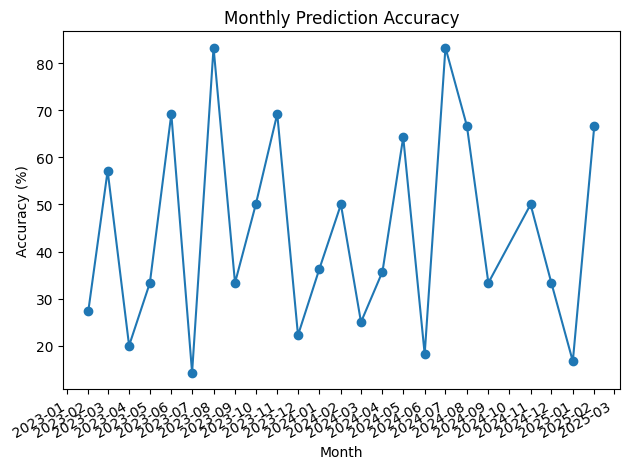

In [78]:
import matplotlib.dates as mdates
pred_df = moving_backtest(df_withbullbear, df_trans, LRtfidf, svd, verbose=False)

# 假設你的 DataFrame 是 pred_df
df = pred_df.copy()

# 1. 轉成 datetime 並加上月份欄
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

# 2. 排除沒有出手 (y_pred == 0)
df_trade = df[df['y_pred'] != 0].copy()

# 3. 計算是否猜對
df_trade['correct'] = df_trade['y_test'] == df_trade['y_pred']

# 4. 按月彙總：總出手天數 & 猜對天數、計算準確率（%）
monthly = (
    df_trade
    .groupby('month')
    .agg(
        trade_days=('correct', 'size'),
        correct_days=('correct', 'sum')
    )
)
monthly['accuracy_%'] = monthly['correct_days'] / monthly['trade_days'] * 100
monthly['do_trade_rate_%'] = monthly['trade_days'] / df.groupby('month')['y_pred'].count() * 100
total_acc = df_trade['correct'].sum() / df_trade['y_pred'].count() * 100
total_traderate = df_trade['y_pred'].count() / df['y_pred'].count() * 100

print(monthly.reset_index())
print(total_acc)
print(total_traderate)


monthly = monthly.reset_index()
monthly['month'] = monthly['month'].dt.to_timestamp()

fig, ax = plt.subplots()
ax.plot(monthly['month'], monthly['accuracy_%'], marker='o')
ax.set_xlabel('Month')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Monthly Prediction Accuracy')

# 每月都顯示一個刻度
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# 自動旋轉 x 軸標籤
fig.autofmt_xdate()

plt.tight_layout()
plt.show()
# Credits: 許智昕

Backtesting: 100%|██████████| 756/756 [01:39<00:00,  7.64it/s] 



📊 Classification Report (Real vs Predicted):
              precision    recall  f1-score   support

          -1      0.554     0.490     0.520       147
           0      0.046     0.625     0.086         8
           1      0.533     0.224     0.315       143

    accuracy                          0.366       298
   macro avg      0.378     0.446     0.307       298
weighted avg      0.530     0.366     0.410       298

      month  trade_days  correct_days  accuracy_%
0   2023-02           9             3   33.333333
1   2023-03          11             8   72.727273
2   2023-04           5             2   40.000000
3   2023-05          10             5   50.000000
4   2023-06          13             9   69.230769
5   2023-07          15             4   26.666667
6   2023-08          10             8   80.000000
7   2023-09           3             1   33.333333
8   2023-10           8             6   75.000000
9   2023-11          12             7   58.333333
10  2023-12           6

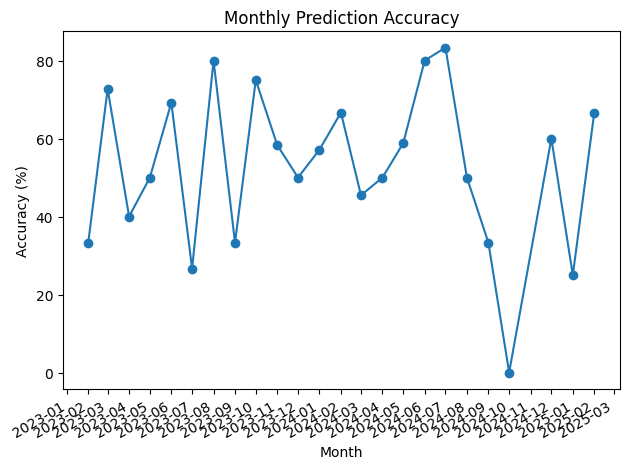

In [ ]:
from datetime import timedelta
from scipy.sparse import vstack
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
from tqdm import tqdm
svd = joblib.load('svd1_model.pkl')  # Load the SVD model
LRtfidf = joblib.load('svc_1_model.pkl')  # Load the Logistic Regression model


def moving_backtest(news_data, trans_data, LRtfidf, svd, verbose=False, use_tqdm=True):
    # 日期轉換與標籤轉換（只做一次）
    news_data = news_data.copy()
    trans_data = trans_data.copy()
    
    # 將 news_data['date'] 轉換為 pd.Timestamp 格式
    news_data['date'] = pd.to_datetime(news_data['post_time']).dt.date
    trans_data['date'] = pd.to_datetime(trans_data['post_time']).dt.date
    news_data['label'] = news_data['Return'].apply(lambda r: 1 if r > 0 else -1 if r < 0 else 0)

    start_date = news_data['date'].min()
    end_date   = news_data['date'].max()

    pred_df = pd.DataFrame(columns=[
        'date', 'y_test', 'y_pred', 
        'pred_up_ratio', 'pred_down_ratio', 'pred_neutral_ratio'
    ])
    
    date_range = list(pd.date_range(start=start_date + timedelta(days=30), end=end_date - timedelta(days=1)))
    date_iterator = tqdm(date_range, desc="Backtesting") if use_tqdm else date_range

    for current_date in date_iterator:
        # 定義訓練/測試區間
        train_start = current_date - timedelta(days=30)
        train_end   = current_date - timedelta(days=1)
        test_start  = current_date
        test_end    = current_date + timedelta(days=1)

        # 將 train_start 和 train_end 轉換為 pd.Timestamp 格式
        train_start = pd.Timestamp(train_start)
        train_end = pd.Timestamp(train_end)
        test_start = pd.Timestamp(test_start)
        test_end = pd.Timestamp(test_end)

        # 訓練和測試資料的日期篩選
        train_mask = (news_data['date'] >= train_start.date()) & (news_data['date'] <= train_end.date())
        test_mask  = (news_data['date'] >= test_start.date()) & (news_data['date'] <= test_end.date())

        X_train_list = news_data.loc[train_mask, 'vector'].tolist()
        y_train = news_data.loc[train_mask, 'label'].tolist()
        X_test_list  = news_data.loc[test_mask, 'vector'].tolist()
        y_test_vals  = news_data.loc[test_mask, 'Return'].tolist()
        y_test = [1 if r > 0 else -1 if r < 0 else 0 for r in y_test_vals]

        # 跳過空資料
        if len(X_train_list) == 0 or len(X_test_list) == 0 or len(np.unique(y_train)) <= 1:
            if verbose:
                print(f"Skipping {current_date} due to insufficient data.")
            continue

        try:
            # 確保 X_train 和 X_test 的形狀一致
            X_train = vstack(X_train_list)
            X_test  = vstack(X_test_list)
        except Exception as e:
            if verbose:
                print(f"Vector stack error at {current_date}: {e}")
            continue

        try:
            # 在訓練集上訓練 SVD 模型，並在測試集上轉換
            X_train_svd = svd.fit_transform(X_train)
            X_test_svd  = svd.transform(X_test)
        except Exception as e:
            if verbose:
                print(f"SVD transform error at {current_date}: {e}")
            continue

        # 訓練 Logistic Regression 模型並預測
        LRtfidf.fit(X_train_svd, y_train)
        y_pred = LRtfidf.predict(X_test_svd)

        # 計算預測結果的投票比例
        up_count = (y_pred == 1).sum()
        down_count = (y_pred == -1).sum()
        neutral_count = (y_pred == 0).sum()
        total_votes = len(y_pred)
        up = int((y_pred == 1).sum())
        down = int((y_pred == -1).sum())
        nums = up + down
        if up > nums*0.8:
            action = 1
        elif down > nums*0.8:
            action = -1
        else:
            action = 0

        # # 投票決策
        # action = 1 if up_count > down_count else -1 if down_count > up_count else 0

        # 真實市場資料
        actual_series = trans_data.loc[trans_data['date'] == pd.Timestamp(current_date).date(), 'change']

        if actual_series.empty:
            continue
        actual = float(actual_series.iloc[0])
        real_movement = 1 if actual > 0 else -1 if actual < 0 else 0

        # 紀錄預測結果
        pred_df.loc[len(pred_df)] = [
            current_date,
            real_movement,
            action,
            round(up_count / total_votes, 3),
            round(down_count / total_votes, 3),
            round(neutral_count / total_votes, 3)
        ]

    # 顯示分類報告
    print("\n📊 Classification Report (Real vs Predicted):")
    print(classification_report(pred_df['y_test'], pred_df['y_pred'], digits=3))

    return pred_df


pred_df = moving_backtest(df_withbullbear, df_trans, LRtfidf, svd, verbose=False)

# 假設你的 DataFrame 是 pred_df
df = pred_df.copy()

# 1. 轉成 datetime 並加上月份欄
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

# 2. 排除沒有出手 (y_pred == 0)
df_trade = df[df['y_pred'] != 0].copy()

# 3. 計算是否猜對
df_trade['correct'] = df_trade['y_test'] == df_trade['y_pred']

# 4. 按月彙總：總出手天數 & 猜對天數、計算準確率（%）
monthly = (
    df_trade
    .groupby('month')
    .agg(
        trade_days=('correct', 'size'),
        correct_days=('correct', 'sum')
    )
)
monthly['accuracy_%'] = monthly['correct_days'] / monthly['trade_days'] * 100
total_acc = df_trade['correct'].sum() / df_trade['y_pred'].count() * 100
total_traderate = df_trade['y_pred'].count() / df['y_pred'].count() * 100

print(monthly.reset_index())
print(total_acc)
print(total_traderate)


monthly = monthly.reset_index()
monthly['month'] = monthly['month'].dt.to_timestamp()

fig, ax = plt.subplots()
ax.plot(monthly['month'], monthly['accuracy_%'], marker='o')
ax.set_xlabel('Month')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Monthly Prediction Accuracy')

# 每月都顯示一個刻度
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# 自動旋轉 x 軸標籤
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

Backtesting: 100%|██████████| 756/756 [01:41<00:00,  7.44it/s] 



📊 Classification Report (Real vs Predicted):
              precision    recall  f1-score   support

          -1      0.554     0.490     0.520       147
           0      0.037     0.500     0.070         8
           1      0.525     0.224     0.314       143

    accuracy                          0.362       298
   macro avg      0.372     0.405     0.301       298
weighted avg      0.526     0.362     0.409       298

      month  trade_days  correct_days  accuracy_%
0   2023-02           9             3   33.333333
1   2023-03          11             8   72.727273
2   2023-04           5             2   40.000000
3   2023-05          10             5   50.000000
4   2023-06          13             9   69.230769
5   2023-07          15             4   26.666667
6   2023-08          10             8   80.000000
7   2023-09           3             1   33.333333
8   2023-10           8             6   75.000000
9   2023-11          12             7   58.333333
10  2023-12           6

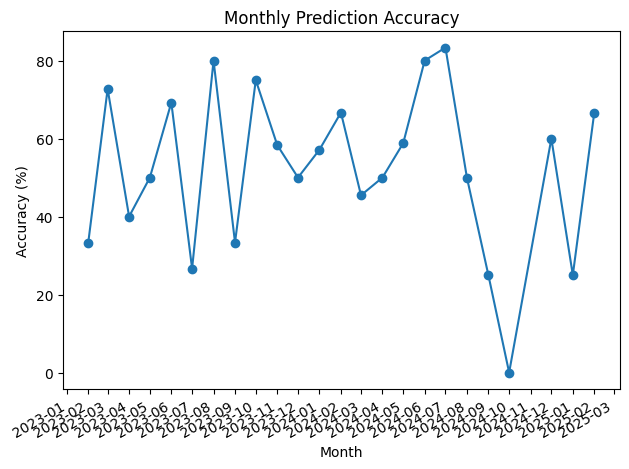

In [81]:
from datetime import timedelta
from scipy.sparse import vstack
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
from tqdm import tqdm
svd = joblib.load('svd3_model.pkl')  # Load the SVD model
LRtfidf = joblib.load('svc_all_model.pkl')  # Load the Logistic Regression model


def moving_backtest(news_data, trans_data, LRtfidf, svd, verbose=False, use_tqdm=True):
    # 日期轉換與標籤轉換（只做一次）
    news_data = news_data.copy()
    trans_data = trans_data.copy()
    
    # 將 news_data['date'] 轉換為 pd.Timestamp 格式
    news_data['date'] = pd.to_datetime(news_data['post_time']).dt.date
    trans_data['date'] = pd.to_datetime(trans_data['post_time']).dt.date
    news_data['label'] = news_data['Return'].apply(lambda r: 1 if r > 0 else -1 if r < 0 else 0)

    start_date = news_data['date'].min()
    end_date   = news_data['date'].max()

    pred_df = pd.DataFrame(columns=[
        'date', 'y_test', 'y_pred', 
        'pred_up_ratio', 'pred_down_ratio', 'pred_neutral_ratio'
    ])
    
    date_range = list(pd.date_range(start=start_date + timedelta(days=30), end=end_date - timedelta(days=1)))
    date_iterator = tqdm(date_range, desc="Backtesting") if use_tqdm else date_range

    for current_date in date_iterator:
        # 定義訓練/測試區間
        train_start = current_date - timedelta(days=30)
        train_end   = current_date - timedelta(days=1)
        test_start  = current_date
        test_end    = current_date + timedelta(days=1)

        # 將 train_start 和 train_end 轉換為 pd.Timestamp 格式
        train_start = pd.Timestamp(train_start)
        train_end = pd.Timestamp(train_end)
        test_start = pd.Timestamp(test_start)
        test_end = pd.Timestamp(test_end)

        # 訓練和測試資料的日期篩選
        train_mask = (news_data['date'] >= train_start.date()) & (news_data['date'] <= train_end.date())
        test_mask  = (news_data['date'] >= test_start.date()) & (news_data['date'] <= test_end.date())

        X_train_list = news_data.loc[train_mask, 'vector'].tolist()
        y_train = news_data.loc[train_mask, 'label'].tolist()
        X_test_list  = news_data.loc[test_mask, 'vector'].tolist()
        y_test_vals  = news_data.loc[test_mask, 'Return'].tolist()
        y_test = [1 if r > 0 else -1 if r < 0 else 0 for r in y_test_vals]

        # 跳過空資料
        if len(X_train_list) == 0 or len(X_test_list) == 0 or len(np.unique(y_train)) <= 1:
            if verbose:
                print(f"Skipping {current_date} due to insufficient data.")
            continue

        try:
            # 確保 X_train 和 X_test 的形狀一致
            X_train = vstack(X_train_list)
            X_test  = vstack(X_test_list)
        except Exception as e:
            if verbose:
                print(f"Vector stack error at {current_date}: {e}")
            continue

        try:
            # 在訓練集上訓練 SVD 模型，並在測試集上轉換
            X_train_svd = svd.fit_transform(X_train)
            X_test_svd  = svd.transform(X_test)
        except Exception as e:
            if verbose:
                print(f"SVD transform error at {current_date}: {e}")
            continue

        # 訓練 Logistic Regression 模型並預測
        LRtfidf.fit(X_train_svd, y_train)
        y_pred = LRtfidf.predict(X_test_svd)

        # 計算預測結果的投票比例
        up_count = (y_pred == 1).sum()
        down_count = (y_pred == -1).sum()
        neutral_count = (y_pred == 0).sum()
        total_votes = len(y_pred)
        up = int((y_pred == 1).sum())
        down = int((y_pred == -1).sum())
        nums = up + down
        if up > nums*0.8:
            action = 1
        elif down > nums*0.8:
            action = -1
        else:
            action = 0

        # # 投票決策
        # action = 1 if up_count > down_count else -1 if down_count > up_count else 0

        # 真實市場資料
        actual_series = trans_data.loc[trans_data['date'] == pd.Timestamp(current_date).date(), 'change']

        if actual_series.empty:
            continue
        actual = float(actual_series.iloc[0])
        real_movement = 1 if actual > 0 else -1 if actual < 0 else 0

        # 紀錄預測結果
        pred_df.loc[len(pred_df)] = [
            current_date,
            real_movement,
            action,
            round(up_count / total_votes, 3),
            round(down_count / total_votes, 3),
            round(neutral_count / total_votes, 3)
        ]

    # 顯示分類報告
    print("\n📊 Classification Report (Real vs Predicted):")
    print(classification_report(pred_df['y_test'], pred_df['y_pred'], digits=3))

    return pred_df


pred_df = moving_backtest(df_withbullbear, df_trans, LRtfidf, svd, verbose=False)

# 假設你的 DataFrame 是 pred_df
df = pred_df.copy()

# 1. 轉成 datetime 並加上月份欄
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

# 2. 排除沒有出手 (y_pred == 0)
df_trade = df[df['y_pred'] != 0].copy()

# 3. 計算是否猜對
df_trade['correct'] = df_trade['y_test'] == df_trade['y_pred']

# 4. 按月彙總：總出手天數 & 猜對天數、計算準確率（%）
monthly = (
    df_trade
    .groupby('month')
    .agg(
        trade_days=('correct', 'size'),
        correct_days=('correct', 'sum')
    )
)
monthly['accuracy_%'] = monthly['correct_days'] / monthly['trade_days'] * 100

total_acc = df_trade['correct'].sum() / df_trade['y_pred'].count() * 100
total_traderate = df_trade['y_pred'].count() / df['y_pred'].count() * 100

print(monthly.reset_index())
print(total_acc)
print(total_traderate)


monthly = monthly.reset_index()
monthly['month'] = monthly['month'].dt.to_timestamp()

fig, ax = plt.subplots()
ax.plot(monthly['month'], monthly['accuracy_%'], marker='o')
ax.set_xlabel('Month')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Monthly Prediction Accuracy')

# 每月都顯示一個刻度
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# 自動旋轉 x 軸標籤
fig.autofmt_xdate()

plt.tight_layout()
plt.show()